In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import openml
import yaml
import tqdm
import time
from pymoo.indicators.hv import HV
import warnings
from multiprocessing import Pool
from joblib import Parallel, delayed
from utility import compute_min_max, get_pareto_front, compute_ranks, compute_extremes, get_all_dataframes, get_group_task_ids
from colors import COLORS
from itertools import product
from concurrent.futures import ProcessPoolExecutor
import autorank


COLOR_LIST = list(COLORS.values())

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

keys = ["random", "so-smac", "mo-smac", "so-asha", "mo-asha", "nsga2"]

In [2]:
with open("./data/classification_meta.yaml", "r") as f:
    meta = yaml.safe_load(f)
with open("./data/regression_meta.yaml", "r") as f:
    meta.update(yaml.safe_load(f))
TASK_IDS = list(meta.keys())
SEEDS = [1, 2, 3, 4, 5]

In [3]:
data_meta = pd.read_csv("./data/base_ensemble_pools_meta.csv")
data = pd.read_csv("./data/base_ensemble_pools.csv", index_col=0)

data_bm = pd.read_csv("./data/base_model_pools.csv", index_col=0)
data_bm = data_bm[data_bm["time"] < 0]
data_bm_meta = pd.read_csv("./data/base_model_pools_meta.csv")

In [4]:
data_merged = data.merge(data_meta, on=["pool_index"])

In [5]:
print(data.head())
print(data_meta.head())
print(data_bm.head())
print(data_bm_meta.head())

          RMSE  inference_time  energy_consumption  ensemble_size  avg_gap  task_id  seed bmg_method  pool_index   RMSE_ens  inference_time_ens  energy_consumption_ens frequency      es_method filter  Log Loss  Log Loss_ens  1 - ROC AUC  1 - ROC AUC_ens
0.0  25.637487        0.227711            0.540527            4.0      0.0   167210     1     random           0  24.204198            0.035958                0.095000  no-boost  energy-qdo-es  nd_50       NaN           NaN          NaN              NaN
1.0  30.312872        0.078179            0.114014            2.0      0.0   167210     1     random           0  27.639710            0.018591                0.037939  no-boost  energy-qdo-es  nd_50       NaN           NaN          NaN              NaN
2.0  21.995853        0.239232            0.555588            4.0      0.0   167210     1     random           0  21.352829            0.042582                0.113577  no-boost  energy-qdo-es  nd_50       NaN           NaN          NaN  

In [6]:
USE_ES_COMBINATIONS = False
USE_CACHED_RESULTS = False

In [7]:
BMG_METHODS_DICT = {
    "random" : "Random Search",
    "nsga2" : "NSGA-II",
    "so-smac" : "SO-SMAC",
    "mo-smac" : "MO-SMAC",
    "so-asha" : "SO-ASHA",
    "mo-asha" : "MO-ASHA",
}
BMG_METHODS = list(BMG_METHODS_DICT.keys())

ENSEMBLING_METHODS_DICT = {
    "bmp" : "BMP",
    "ges" : "GES",
    "mo-ges" : "MO-GES",
    "qdo-es" : "QDO-ES",
    "infer-qdo-es" : "Infer-QDO-ES",
    "size-qdo-es" : "Size-QDO-ES",
    "energy-qdo-es" : "Energy-QDO-ES",
}
ENSEMBLING_METHODS = list(ENSEMBLING_METHODS_DICT.keys())

if USE_ES_COMBINATIONS:
    ENSEMBLING_METHODS_DICT.update({
        "ges+mo-ges" : "GES + MO-GES",
        "ges+qdo-es" : "GES + QDO-ES",
        "ges+infer-qdo-es" : "GES + Infer-QDO-ES",
        "mo-ges+qdo-es" : "MO-GES + QDO-ES",
        "mo-ges+infer-qdo-es" : "MO-GES + Infer-QDO-ES",
        "infer-qdo-es+qdo-es" : "Infer-QDO-ES + QDO-ES",
    })
ENSEMBLING_METHODS = list(ENSEMBLING_METHODS_DICT.keys())

PRUNING_METHODS_DICT = {
    "top_50" : "Top 50",
    "silo_top_50" : "Silo Top 50",
    "nd_50" : "NDS Top 50",
    "nd_50_silo" : "Silo NDS Top 50",
    "nd_first_pareto" : "Pareto Rank =1",
    "nd_second_pareto" : "Pareto Rank ≤2",
    "nd_third_pareto" : "Pareto Rank ≤3",
}
PRUNING_METHODS = list(PRUNING_METHODS_DICT.keys())
PRUNING_METHODS_SMALL = ["none", "nd_first_pareto", "nd_second_pareto", "nd_third_pareto"]


FREQUENCIES = ["boost", "no-boost"]

In [8]:
if not os.path.exists("./data/processed_data"):
    os.makedirs("./data/processed_data")

if os.path.exists("./data/processed_data/min_max.yaml"):
    with open("./data/processed_data/min_max.yaml", "r") as f:
        min_max_values = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    min_max_values = compute_min_max(all_df)
    with open("./data/processed_data/min_max.yaml", "w") as f:
        yaml.dump(min_max_values, f)
    del all_df
assert len(min_max_values) == 104

In [9]:
if os.path.exists("./data/processed_data/extremes.yaml"):
    with open("./data/processed_data/extremes.yaml", "r") as f:
        extremes = yaml.safe_load(f)
else:
    all_df = get_all_dataframes()
    extremes = compute_extremes(min_max_values, all_df)
    with open("./data/processed_data/extremes.yaml", "w") as f:
        yaml.dump(extremes, f)
    del all_df
assert len(extremes) == 104

In [10]:
def min_distance(vectors, paret_front, ignore_self=False):
    diff = vectors[:, None, :] - paret_front[None, :, :]
    dist = np.linalg.norm(diff, axis=2)
    if ignore_self:
        np.fill_diagonal(dist, np.inf)
    return np.min(dist, axis=1)

def compute_spread(extent, sum_deviations, denom):
    assert np.isfinite(extent) and np.isfinite(sum_deviations) and np.isfinite(denom), "Values must be finite"
    return (extent + sum_deviations) / (extent + denom)

def compute_extent(pareto_front, cols, extremes):
    extremes_array = np.array([[e[col] for col in cols] for e in extremes.values()])
    sum_extremes = np.sum(min_distance(extremes_array, pareto_front))
    return sum_extremes

def compute_uniformity_components(pareto_front, cols):
    assert len(pareto_front) > 0, "Pareto front is empty"
    if len(pareto_front) == 1:
        return 1.0, 1.0 

    distances = min_distance(pareto_front, pareto_front, ignore_self=True)
    assert not np.any(np.isinf(distances)), "Distances contain infinity"
        
    d_mean = np.mean(distances)
    assert np.abs(d_mean) >= 1e-14, "Mean distance is too small"

    sum_deviations = np.sum(np.abs(distances - d_mean))
    return sum_deviations, len(pareto_front) * d_mean

def compute_uniformity(sum_deviations, denom):
    return sum_deviations / denom


def filter_duplicates(arr):
    unique = []
    for row in arr:
        if not any(np.abs(row - u).sum() < 1e-6 for u in unique):
            unique.append(row)
    return np.array(unique)

In [11]:
def compute_hvs(data, log_mask, min_arr, max_arr):
    ind = HV(ref_point=[1] * 3)
    data_norm = (data - min_arr) / (max_arr - min_arr)
    hv = ind(data_norm)
    
    data_log_scaled = data.copy()
    data_log_scaled[:, log_mask] = np.log10(data_log_scaled[:, log_mask] + 1e-10)
    min_arr_log = min_arr.copy()
    min_arr_log[log_mask] = np.log10(min_arr_log[log_mask] + 1e-10)
    max_arr_log = max_arr.copy()
    max_arr_log[log_mask] = np.log10(max_arr_log[log_mask] + 1e-10)
    data_log_norm = (data_log_scaled - min_arr_log) / (max_arr_log - min_arr_log)
    hv_log = ind(data_log_norm)
    return hv, hv_log, data_norm

In [12]:
pred_metrics_per_task = {}

def process(data_grouped, data_bm_grouped, task_id, seed, bmg_method, frequency):
    i_task_id = TASK_IDS.index(task_id)
    i_bmg_method = BMG_METHODS.index(bmg_method)
    i_frequency = FREQUENCIES.index(frequency)
    i_seed = seed - 1

    results_list = []

    try:
        group = data_bm_grouped.get_group((task_id, seed, bmg_method, frequency))
    except Exception as e:
        for (ensembling_method, pruning_method) in product(ENSEMBLING_METHODS, PRUNING_METHODS):
            i_ensembling_method = ENSEMBLING_METHODS.index(ensembling_method)
            i_pruning_method = PRUNING_METHODS.index(pruning_method)

            metrics = [
                0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
                np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan,
                0.0, 0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
            ]

            results_list.append((i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, metrics))
        assert len(results_list) == len(ENSEMBLING_METHODS) * len(PRUNING_METHODS), f"Unexpected number of results computed. ({len(results_list)})"
        return results_list

    cols = ["RMSE", "Log Loss", "1 - ROC AUC", "inference_time", "energy_consumption"]
    cols = [col for col in cols if (~group[col].isna()).sum() > 0]
    assert len(cols) == 3, f"Expected 3 performance metrics for task {task_id}, got {len(cols)}"
    
    cols_ens = [f"{c}_ens" for c in cols]
    
    log_mask = [1,2]

    pred_metrics_per_task[task_id] = cols[0]

    start = time.time()

    min_dict, max_dict = min_max_values[task_id]
    min_arr, max_arr = np.array([min_dict[col] for col in cols]), np.array([max_dict[col] for col in cols])
    extreme_solutions = extremes[task_id]

    # bmp_data_norm = group[cols].values
    # bmp_data_norm = (bmp_data_norm - min_arr) / (max_arr - min_arr)
    # ind = HV(ref_point=[1] * len(cols))
    # hv_bmp = ind(bmp_data_norm)
    # #hv_bmp_log = compute_log_hv(bmp_data_norm, log_mask=log_mask)
    # hv_bmp_log = compute_log_hv(group[cols].values, log_mask=log_mask, max_arr=max_arr)
    
    data_bmp = group[cols].values
    pareto_bmp_ens_mask = get_pareto_front(group[cols_ens].values)
    data_bmp = data_bmp[pareto_bmp_ens_mask]
    
    hv_bmp, hv_bmp_log, bmp_data_norm = compute_hvs(data_bmp, log_mask, min_arr, max_arr)
    
    pareto_bmp_mask = get_pareto_front(bmp_data_norm)
    pareto_bmp = bmp_data_norm[pareto_bmp_mask]
    pareto_bmp = filter_duplicates(pareto_bmp)

    n_pareto_bmp = len(pareto_bmp)
    uniformity_bmp_sum_dev, uniformity_bmp_denom = compute_uniformity_components(pareto_bmp, cols)
    uniformity_bmp = compute_uniformity(uniformity_bmp_sum_dev, uniformity_bmp_denom)
    extent_bmp = compute_extent(pareto_bmp, cols, extreme_solutions)
    spread_bmp = compute_spread(extent_bmp, uniformity_bmp_sum_dev, uniformity_bmp_denom)


    best_single_bmp = []
    for i, col in enumerate(cols):
        best_single_bmp.append(bmp_data_norm[:, i].min())


    ens_data = data_grouped.get_group((task_id, seed, bmg_method, frequency))
    has_none_pruning = "none" in ens_data["filter"].values
    ens_data_grouped = ens_data.groupby(["es_method", "filter"])


    for (ensembling_method, pruning_method) in product(ENSEMBLING_METHODS, PRUNING_METHODS):
        if has_none_pruning and pruning_method in ["top_50", "silo_top_50", "nd_50", "nd_50_silo"]:
            pruning_method_group_indexer = "none"
        else:
            pruning_method_group_indexer = pruning_method

        i_ensembling_method = ENSEMBLING_METHODS.index(ensembling_method)
        i_pruning_method = PRUNING_METHODS.index(pruning_method)

        if "+" in ensembling_method:
            methods = ensembling_method.split("+")
            combined_ens_data = []
            for method in methods:
                try:
                    method_group = ens_data_grouped.get_group((method, pruning_method_group_indexer))
                    combined_ens_data.append(method_group)
                except Exception as e:
                    combined_ens_data = []
                    break
            if len(combined_ens_data) == 0:
                metrics = [
                    hv_bmp, hv_bmp, 0.0, hv_bmp_log, hv_bmp_log, 0.0, n_pareto_bmp, n_pareto_bmp, n_pareto_bmp, spread_bmp, spread_bmp, spread_bmp,
                    extent_bmp, extent_bmp, extent_bmp, uniformity_bmp, uniformity_bmp, uniformity_bmp,
                    0.0, 0, 0.0, 0.0,
                    *best_single_bmp, *best_single_bmp
                ]
                results_list.append((i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, metrics))
                continue
            ens_group = pd.concat(combined_ens_data, ignore_index=True)
        elif ensembling_method == "bmp":
            ens_group = group[pareto_bmp_ens_mask]
        else:
            try:
                ens_group = ens_data_grouped.get_group((ensembling_method, pruning_method_group_indexer))
            except Exception as e:
                metrics = [
                    hv_bmp, hv_bmp, 0.0, hv_bmp_log, hv_bmp_log, 0.0, n_pareto_bmp, n_pareto_bmp, n_pareto_bmp, spread_bmp, spread_bmp, spread_bmp,
                    extent_bmp, extent_bmp, extent_bmp, uniformity_bmp, uniformity_bmp, uniformity_bmp,
                    0.0, 0, 0.0, 0.0,
                    *best_single_bmp, *best_single_bmp
                ]
                results_list.append((i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, metrics))
                continue

        start = time.time()

        # ens_data_norm = ens_group[cols].values
        # ens_data_norm = (ens_data_norm - min_arr) / (max_arr - min_arr)
        # full_data_norm = np.vstack([bmp_data_norm, ens_data_norm])
        
        ens_data = ens_group[cols].values
        ens_data_pareto_ens_mask = get_pareto_front(ens_group[cols_ens].values)
        ens_data = ens_data[ens_data_pareto_ens_mask]
        
        bmp_ens_data = np.vstack([data_bmp, ens_data])
        #bmp_ens_data_pareto_ens_mask = get_pareto_front(np.vstack([group[cols_ens].values, ens_group[cols_ens].values]))
        #bmp_ens_data = bmp_ens_data[bmp_ens_data_pareto_ens_mask]
        
        hv, hv_log, ens_data_norm = compute_hvs(ens_data, log_mask, min_arr, max_arr)
        hv_incl_bmp, hv_log_incl_bmp, full_data_norm = compute_hvs(bmp_ens_data, log_mask, min_arr, max_arr)

        #hv = ind(ens_data_norm)
        #hv_incl_bmp = ind(full_data_norm)
        rel_hv_improvement = (hv_incl_bmp - hv_bmp) / hv_bmp
        
        #hv_log = compute_log_hv(ens_data_norm, log_mask=log_mask)
        #hv_log_incl_bmp = compute_log_hv(full_data_norm, log_mask=log_mask)
        #hv_log = compute_log_hv(ens_group[cols].values, log_mask=log_mask, max_arr=max_arr)
        #hv_log_incl_bmp = compute_log_hv(np.vstack([ens_group[cols].values, group[cols].values]), log_mask=log_mask, max_arr=max_arr)
        rel_hv_log_improvement = (hv_log_incl_bmp - hv_bmp_log) / hv_bmp_log
        
        pareto_ensembling_mask = get_pareto_front(ens_data_norm)
        pareto_full_mask = get_pareto_front(full_data_norm)
        pareto_ensembling = ens_data_norm[pareto_ensembling_mask]
        pareto_full = full_data_norm[pareto_full_mask]
        pareto_ensembling = filter_duplicates(pareto_ensembling)
        pareto_full = filter_duplicates(pareto_full)

        n_pareto_ensembling = len(pareto_ensembling)
        n_pareto_full = len(pareto_full)

        uniformity_ensembling_sum_dev, uniformity_ensembling_denom = compute_uniformity_components(pareto_ensembling, cols)
        uniformity_full_sum_dev, uniformity_full_denom = compute_uniformity_components(pareto_full, cols)

        uniformity_ensembling = compute_uniformity(uniformity_ensembling_sum_dev, uniformity_ensembling_denom)
        uniformity_full = compute_uniformity(uniformity_full_sum_dev, uniformity_full_denom)

        extent_ensembling = compute_extent(pareto_ensembling, cols, extreme_solutions)
        extent_full = compute_extent(pareto_full, cols, extreme_solutions)

        spread_ensembling = compute_spread(extent_ensembling, uniformity_ensembling_sum_dev, uniformity_ensembling_denom)
        spread_full = compute_spread(extent_full, uniformity_full_sum_dev, uniformity_full_denom)

        pool_indices = ens_group["pool_index"].unique()
        n_plus = ensembling_method.count("+")
        assert len(pool_indices) == n_plus + 1, f"Expected {n_plus + 1} pool indices for ensembling method {ensembling_method}, got {len(pool_indices)}"

        runtime, n_models, pred_time_sum, pred_energy_sum = 0.0, 0, 0.0, 0.0
        if ensembling_method == "bmp":
            runtime = 0
            n_models = 0
            pred_time_sum = 0
            pred_energy_sum = 0
        else:
            for pool_index in pool_indices:
                meta = data_meta[data_meta["pool_index"] == pool_index].iloc[0]
                # Runtime sums over all ensembling methods
                runtime += meta["runtime"]
                # All ensembling methods use same pool, so n_models is same for all => "=" instead of "+="
                n_models = meta["n_models"] 
                pred_time_sum = meta["sum_pred_time"]
                pred_energy_sum = meta["sum_pred_energy"] 

        best_single_ensembling = []
        for i, col in enumerate(cols):
            best_single_ensembling.append(ens_data_norm[:, i].min())

        metrics = [
            hv, hv_incl_bmp, rel_hv_improvement, 
            hv_log, hv_log_incl_bmp, rel_hv_log_improvement,
            n_pareto_ensembling, n_pareto_full, n_pareto_bmp,
            spread_ensembling, spread_full, spread_bmp, 
            extent_ensembling, extent_full, extent_bmp,
            uniformity_ensembling, uniformity_full, uniformity_bmp,
            runtime, n_models, pred_time_sum, pred_energy_sum,
            *best_single_bmp, *best_single_ensembling
        ]

        results_list.append((i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, metrics))

    assert len(results_list) == len(ENSEMBLING_METHODS) * len(PRUNING_METHODS), f"Unexpected number of results computed. ({len(results_list)})"
    
    return results_list



In [13]:
data_bm_grouped = data_bm.groupby(["task_id", "seed", "bmg_method", "frequency"])
data_grouped = data.groupby(["task_id", "seed", "bmg_method", "frequency"])

RESULTS_ORDER = [
    "Hypervolume", "Hypervolume incl. BMP", "Relative Hypervolume Improvement",
    "Log Hypervolume", "Log Hypervolume incl. BMP", "Relative Log Hypervolume Improvement",
    "Size of Pareto Front", "Size of Pareto Front incl. BMP", "Size of Pareto Front BMP", "Spread", "Spread incl. BMP", "Spread BMP", 
    "Extent Ensembling", "Extent Full", "Extent BMP", "Uniformity Ensembling", "Uniformity Full", "Uniformity BMP", "Runtime Ensembling",
    "Number of Models", "Sum of Prediction Times", "Sum of Prediction Energies", "Predictive Metric BMP", "Inference Time BMP",
    "Energy Consumption BMP", "Predictive Metric Ensembling", "Inference Time Ensembling", "Energy Consumption Ensembling"
]
results_arr = np.zeros((2, 104, len(BMG_METHODS), 5, len(ENSEMBLING_METHODS), len(PRUNING_METHODS), len(RESULTS_ORDER))) + np.nan

n_total = len(TASK_IDS) * len(SEEDS) * len(BMG_METHODS) * len(FREQUENCIES)

def process_wrapper(args):
    task_id, seed, bmg_method, frequency = args
    res = process(data_grouped, data_bm_grouped, task_id, seed, bmg_method, frequency)
    return res

if os.path.exists("./data/processed_data/ens_processed.npy") and USE_CACHED_RESULTS:
    results_arr = np.load("./data/processed_data/ens_processed.npy")
else:
    jobs = list(product(TASK_IDS, SEEDS, BMG_METHODS, FREQUENCIES))
        
    with ProcessPoolExecutor(max_workers=12) as executor:
        for results_list in tqdm.tqdm(
            executor.map(process_wrapper, jobs), total=len(jobs)
        ):
            for (i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, metrics) in results_list:
                results_arr[i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, :] = metrics
                                                                            
    # for job in tqdm.tqdm(jobs):
    #     results_list = process_wrapper(job)
    #     for (i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, metrics) in results_list:
    #         results_arr[i_frequency, i_task_id, i_bmg_method, i_seed, i_ensembling_method, i_pruning_method, :] = metrics
                    
                        
    np.save("./data/processed_data/ens_processed.npy", results_arr)


100%|██████████| 6240/6240 [01:13<00:00, 84.65it/s] 


In [14]:
for i, metric in enumerate(RESULTS_ORDER):
    arr = results_arr[..., i]
    print(f"For metric {metric}, {np.sum(np.isfinite(arr)) / np.prod(arr.shape)*100:.3f} % values are finite")

For metric Hypervolume, 100.000 % values are finite
For metric Hypervolume incl. BMP, 100.000 % values are finite
For metric Relative Hypervolume Improvement, 100.000 % values are finite
For metric Log Hypervolume, 100.000 % values are finite
For metric Log Hypervolume incl. BMP, 100.000 % values are finite
For metric Relative Log Hypervolume Improvement, 100.000 % values are finite
For metric Size of Pareto Front, 100.000 % values are finite
For metric Size of Pareto Front incl. BMP, 100.000 % values are finite
For metric Size of Pareto Front BMP, 100.000 % values are finite
For metric Spread, 99.808 % values are finite
For metric Spread incl. BMP, 99.808 % values are finite
For metric Spread BMP, 99.808 % values are finite
For metric Extent Ensembling, 99.808 % values are finite
For metric Extent Full, 99.808 % values are finite
For metric Extent BMP, 99.808 % values are finite
For metric Uniformity Ensembling, 99.808 % values are finite
For metric Uniformity Full, 99.808 % values ar

In [15]:
for i_task in range(len(TASK_IDS)):
    for i_freq in range(len(FREQUENCIES)):
        arr = results_arr[i_freq, i_task, :, :, :, :, :]

        for metric in [
            "Spread", "Spread incl. BMP", "Spread BMP",
            "Extent Ensembling", "Extent Full", "Extent BMP",
            "Uniformity Ensembling", "Uniformity Full", "Uniformity BMP"
        ]:
            # For empty ensemble pools, use max value imputation
            mask = ~np.isfinite(arr[..., RESULTS_ORDER.index(metric)])
            max_val = np.nanmax(arr[..., RESULTS_ORDER.index(metric)][~mask])
            results_arr[i_freq, i_task, :, :, :, :, RESULTS_ORDER.index(metric)][mask] = max_val


In [16]:
for i, metric in enumerate(RESULTS_ORDER):
    arr = results_arr[..., i]
    print(f"For metric {metric}, {np.sum(np.isfinite(arr)) / np.prod(arr.shape)*100:.3f} % values are finite")

For metric Hypervolume, 100.000 % values are finite
For metric Hypervolume incl. BMP, 100.000 % values are finite
For metric Relative Hypervolume Improvement, 100.000 % values are finite
For metric Log Hypervolume, 100.000 % values are finite
For metric Log Hypervolume incl. BMP, 100.000 % values are finite
For metric Relative Log Hypervolume Improvement, 100.000 % values are finite
For metric Size of Pareto Front, 100.000 % values are finite
For metric Size of Pareto Front incl. BMP, 100.000 % values are finite
For metric Size of Pareto Front BMP, 100.000 % values are finite
For metric Spread, 100.000 % values are finite
For metric Spread incl. BMP, 100.000 % values are finite
For metric Spread BMP, 100.000 % values are finite
For metric Extent Ensembling, 100.000 % values are finite
For metric Extent Full, 100.000 % values are finite
For metric Extent BMP, 100.000 % values are finite
For metric Uniformity Ensembling, 100.000 % values are finite
For metric Uniformity Full, 100.000 % v

In [17]:
def compare_pruning_full(task_ids, results_arr, frequency, metric, mode="max", use_ranks=True, metric_rename=None, save_path=None, ignore_no_ens=True):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = FREQUENCIES.index(frequency)
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)

    fig, ax = plt.subplots(figsize=(18, len(ENSEMBLING_METHODS)*1.3), ncols=3, nrows=2)
    ax = ax.flatten()

    # Compute shared vmin/vmax for consistent color scale
    if use_ranks:
        vmin, vmax = 1, len(ENSEMBLING_METHODS) * len(PRUNING_METHODS)
    else:
        all_means = []
        for i_bmg in range(len(BMG_METHODS)):
            vals = metric_vals_mean[:, i_bmg, :, :].mean(axis=0)
            #vals = vals[np.ix_(ES_ORDER_IDX, PRUNE_ORDER_IDX)]
            all_means.append(vals)
        all_means = np.stack(all_means)
        vmin, vmax = all_means.min(), all_means.max()

    # Create a single colorbar axis
    cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

    if mode == "max":
        cmap = "viridis" if use_ranks else "viridis_r"
    else:
        cmap = "viridis_r" if use_ranks else "viridis"

    for i_method, bmg_method in enumerate(BMG_METHODS):
        i_bmg = BMG_METHODS.index(bmg_method)
        if use_ranks:
            ensembling_methods_valid = ENSEMBLING_METHODS
            if ignore_no_ens:
                # Exclude "bmp" ensembling method from ranking
                valid_ensembling_indices = [i for i, em in enumerate(ENSEMBLING_METHODS) if em != "bmp"]
                ensembling_methods_valid = [em for em in ENSEMBLING_METHODS if em != "bmp"]
                filtered_metric_vals_mean = metric_vals_mean[:, i_bmg, valid_ensembling_indices, :]
                flattened = filtered_metric_vals_mean.reshape((104, -1))  # shape: (104, (6-1)*7)
            else:
                flattened = metric_vals_mean[:, i_bmg, :, :].reshape((104, -1))  # shape: (104, 42)            
            ranks = compute_ranks(flattened, mode=mode, axis=1)  # shape: (104, 42)
            ranks = ranks.reshape((104, len(ensembling_methods_valid), len(PRUNING_METHODS)))
            mean_ranks = ranks.mean(axis=0)  # shape: (6, 7)
            std_ranks = ranks.std(axis=0)    # shape: (6, 7)
            vmin, vmax = mean_ranks.min(), mean_ranks.max()
            

            # Combine mean and std into formatted strings
            annot = np.empty(mean_ranks.shape, dtype=object)
            for i in range(mean_ranks.shape[0]):
                for j in range(mean_ranks.shape[1]):
                    annot[i, j] = f"{mean_ranks[i, j]:.3f}\n({std_ranks[i, j]:.3f})"

            sns.heatmap(
                mean_ranks,
                annot=annot,
                fmt="",
                cmap=cmap,
                ax=ax[i_method],
                vmin=vmin,
                vmax=vmax,
                cbar=i_method == 0,  # Only first plot adds colorbar
                cbar_ax=cbar_ax if i_method == 0 else None,
                annot_kws={"size": 8},
            )
            
            # Highlight best rank
            best_i, best_j = np.unravel_index(np.argmin(mean_ranks), mean_ranks.shape)
            ax[i_method].add_patch(plt.Rectangle((best_j, best_i), 1, 1, fill=False, edgecolor='black', lw=1.5))
        else:
            mean_vals = metric_vals_mean[:, i_bmg, :, :].mean(axis=0)  # shape: (6, 7)
            std_vals = metric_vals_mean[:, i_bmg, :, :].std(axis=0)   # shape: (6, 7)

            # Combine mean and std into formatted strings
            annot = np.empty(mean_vals.shape, dtype=object)
            for i in range(mean_vals.shape[0]):
                for j in range(mean_vals.shape[1]):
                    annot[i, j] = f"{mean_vals[i, j]:.3f}\n({std_vals[i, j]:.3f})"

            sns.heatmap(
                mean_vals,
                annot=annot,
                fmt="",
                cmap=cmap,
                ax=ax[i_method],
                vmin=vmin,
                vmax=vmax,
                cbar=i_method == 0,  # Only first plot adds colorbar
                cbar_ax=cbar_ax if i_method == 0 else None,
                annot_kws={"size": 8},
            )

        ax[i_method].set_title(BMG_METHODS_DICT[bmg_method], fontsize=10)
        
        xlabels = ["\nRank".join(PRUNING_METHODS_DICT[p].split(" Rank")) for p in PRUNING_METHODS]
        xlabels = ["Silo NDS\nTop 50" if xl == "Silo NDS Top 50" else xl for xl in xlabels]

        ax[i_method].set_xticklabels(xlabels, rotation=45, ha="right", fontsize=10)
        ax[i_method].set_yticklabels([ENSEMBLING_METHODS_DICT[e] for e in (ensembling_methods_valid if (ignore_no_ens and use_ranks) else ENSEMBLING_METHODS)], rotation=0, fontsize=10)

    # Label shared colorbar
    if metric_rename is not None:
        metric = metric_rename
    cbar_ax.set_ylabel(f"{metric} {'Ranks' if use_ranks else ''}", fontsize=12)
    cbar_ax.tick_params(labelsize=10)

    plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()

In [18]:

from matplotlib.patches import Rectangle

def compare_pruning_aggregated(task_ids, results_arr, frequency, metric, mode="max", metric_rename=None, use_ranks=True, save_path=None):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = FREQUENCIES.index(frequency)
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)

    fig, ax = plt.subplots(figsize=(8,7))

    cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
    
    arr = np.zeros((len(ENSEMBLING_METHODS)-1, len(PRUNING_METHODS), 2))  # Exclude BMP row
    opt_row_inidices = []
    
    for i_ensembling, ensembling_method in enumerate([e for e in ENSEMBLING_METHODS if e != "bmp"]):
        ensembling_idx = ENSEMBLING_METHODS.index(ensembling_method)
        reshaped = metric_vals_mean[:, :, ensembling_idx, :].reshape((104 * len(BMG_METHODS), -1))  # shape: (104*6, 7)
        if use_ranks:
            ranks = compute_ranks(reshaped, mode=mode, axis=1)  # shape: (104*6, 7)
            arr[i_ensembling, :, 0] = ranks.mean(axis=0)
            arr[i_ensembling, :, 1] = ranks.std(axis=0)
        else:
            arr[i_ensembling, :, 0] = reshaped.mean(axis=0)
            arr[i_ensembling, :, 0] = arr[i_ensembling, :, 0] / arr[i_ensembling, :, 0].max()
        
        if mode == "min" and use_ranks or mode == "max" and not use_ranks:
            opt_row_inidices.append(np.argmax(arr[i_ensembling, :, 0]))
        else:
            opt_row_inidices.append(np.argmin(arr[i_ensembling, :, 0]))
            
    cmap = "viridis" if use_ranks else "viridis_r"
    vmin, vmax = arr[:, :, 0].min(), arr[:, :, 0].max()

    # Combine mean and std into formatted strings
    annot = np.empty((arr.shape[0], arr.shape[1]), dtype=object)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            if use_ranks:
                annot[i, j] = f"{arr[i, j, 0]:.3f}\n({arr[i, j, 1]:.3f})"
            else:
                annot[i, j] = f"{arr[i, j, 0]:.4f}"

    sns.heatmap(
        arr[:, :, 0],
        annot=annot,
        fmt="",
        cmap=cmap,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        cbar=True,  # Only first plot adds colorbar
        cbar_ax=cbar_ax,
        annot_kws={"size": 9},
    )
    
    # Mark min values
    for i, j in enumerate(opt_row_inidices):
        # Rectangle patch (x, y, width, height)
        rect = Rectangle(
            (j, i),        # lower-left corner
            1, 1,          # width, height
            fill=False,
            edgecolor="black",
            linewidth=1.5
        )
        ax.add_patch(rect)
            
    ax.set_xticklabels([PRUNING_METHODS_DICT[p] for p in PRUNING_METHODS], rotation=45, ha="right", fontsize=10)
    ax.set_yticklabels([ENSEMBLING_METHODS_DICT[e] for e in ENSEMBLING_METHODS if e != "bmp"], rotation=0, fontsize=10)

    # Label shared colorbar
    cbar_ax.set_ylabel(f"{metric_rename if metric_rename else metric} {'Ranks' if use_ranks else ''}", fontsize=12)
    cbar_ax.tick_params(labelsize=10)
    cbar_ax.yaxis.label.set_size(12)

    plt.tight_layout(rect=[0, 0, 0.92, .879])  # Leave room for colorbar
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()

/tmp/ipykernel_95367/847692710.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, .879])  # Leave room for colorbar
/tmp/ipykernel_95367/847692710.py:77: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, .879])  # Leave room for colorbar


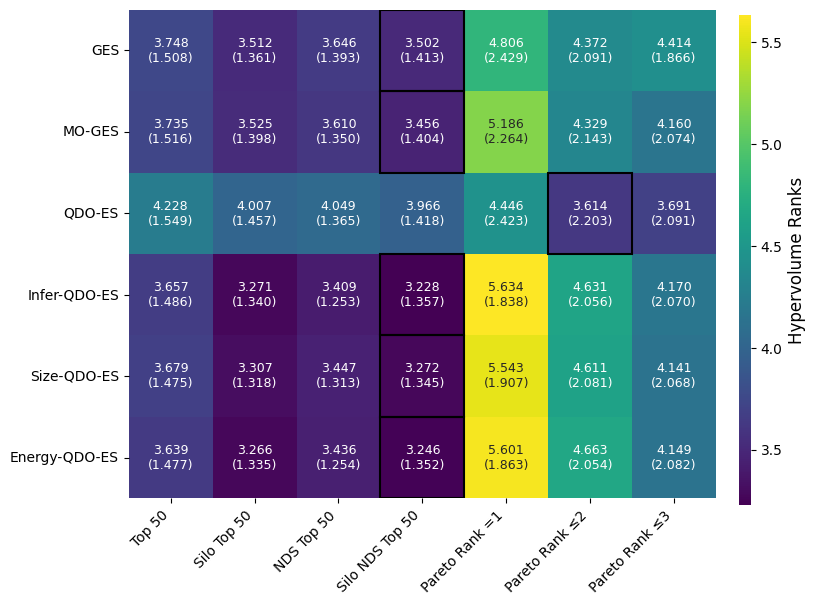

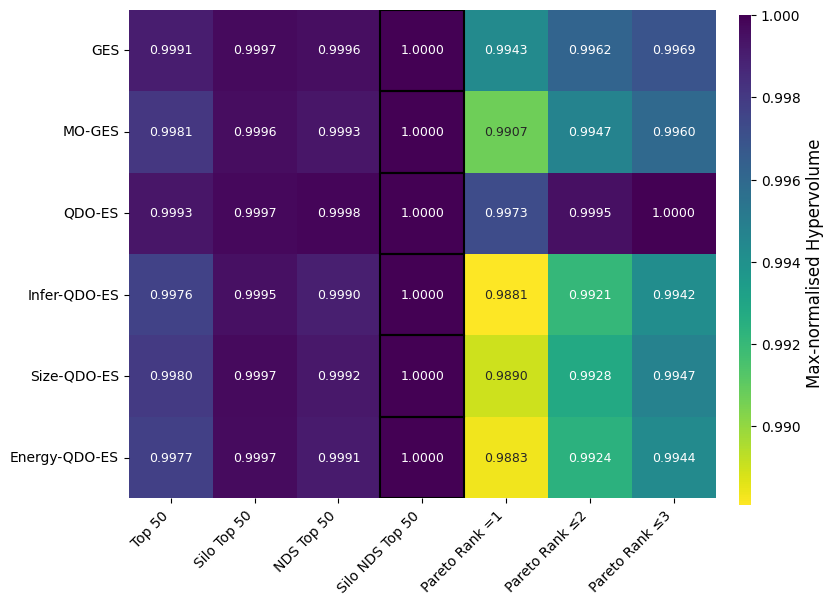

In [19]:
compare_pruning_aggregated(TASK_IDS, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", mode="max", metric_rename="Hypervolume", save_path="./figures/ens/ens_pruning_hv_ranks.pdf", use_ranks=True)
compare_pruning_aggregated(TASK_IDS, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", mode="max", metric_rename="Max-normalised Hypervolume", save_path="./figures/ens/ens_pruning_hv_norm.pdf", use_ranks=False)

/tmp/ipykernel_95367/4245406557.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])  # Leave room for colorbar


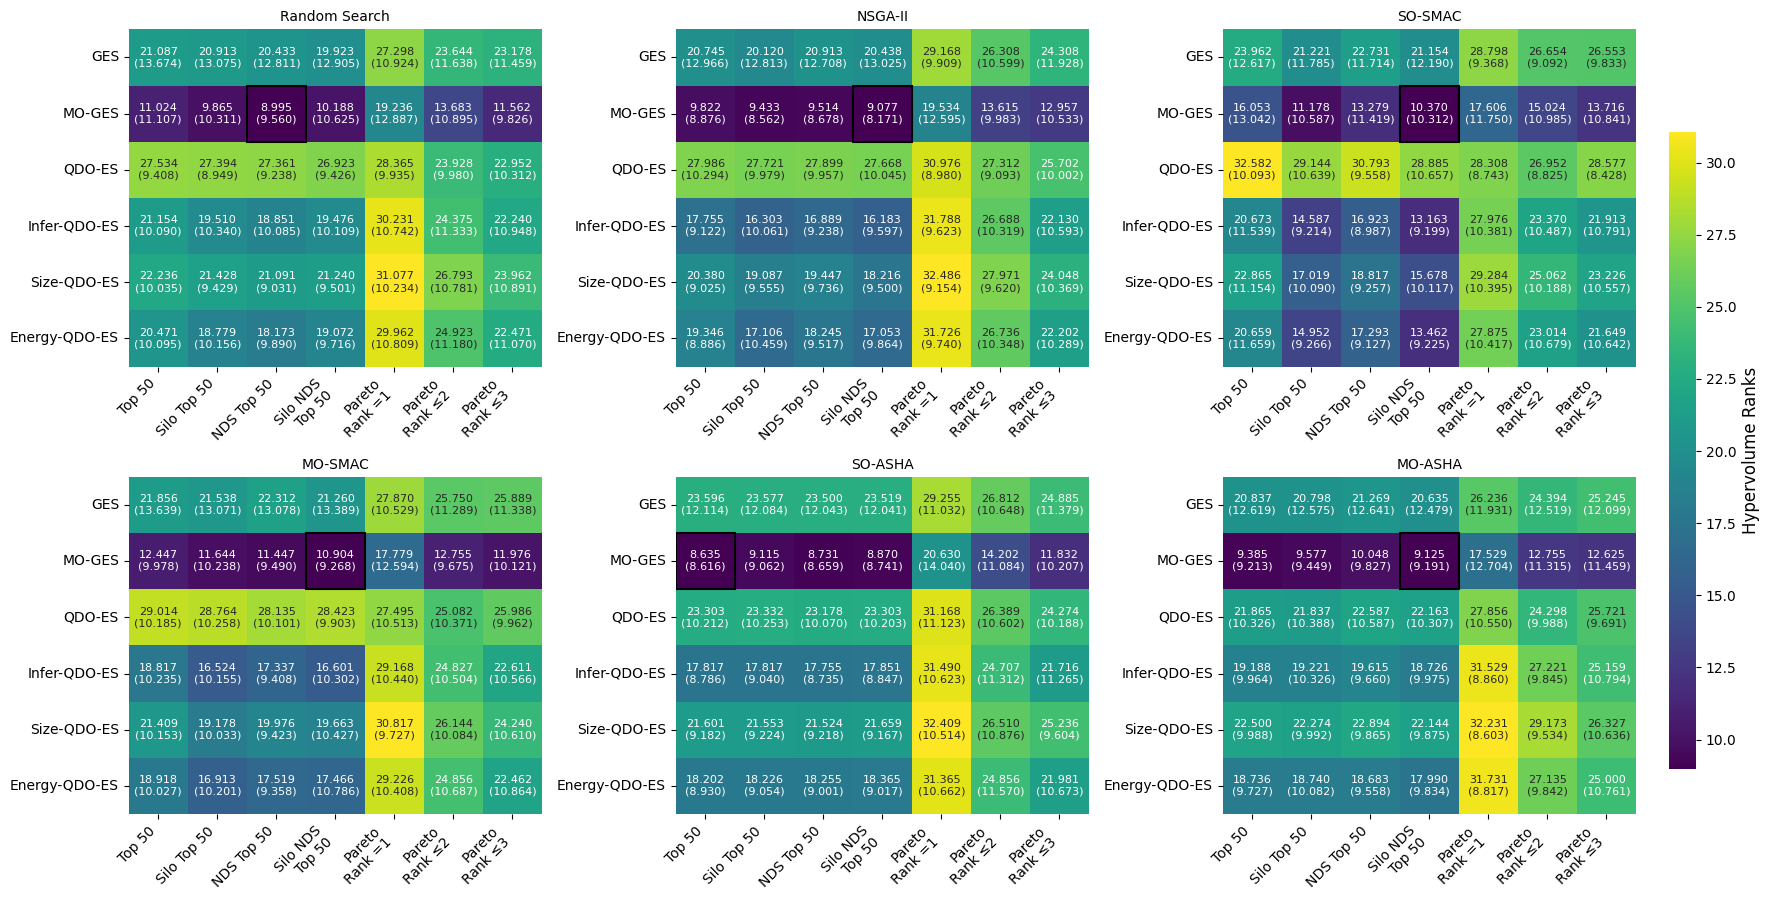

In [20]:
compare_pruning_full(TASK_IDS, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", use_ranks=True, metric_rename="Hypervolume", save_path="./figures/ens/ens_pruning_full_hv_ranks.pdf")

In [21]:
from matplotlib.patches import Patch

def compare_pruning_tradeoffs(task_ids, results_arr, frequency, save_path=None):
    metrics = ["Number of Models", "Runtime Ensembling"]   # two metrics
    colors = COLOR_LIST[:2]  # two colors

    # Load/prune data
    data = results_arr[FREQUENCIES.index(frequency)]
    data = data[:, :, :, :, :, [RESULTS_ORDER.index(m) for m in metrics]]
    data = data.reshape((-1, 7, len(metrics)))

    fig, ax = plt.subplots(figsize=(7, 6))

    # Three pruning groups
    indices_used = [4, 5, 6]
    prune_order_used = [PRUNING_METHODS[i] for i in indices_used]

    all_data = []
    positions = []
    base_positions = []
    labels = []
    pos = 1

    for g, prune_idx in enumerate(indices_used):
        base_positions.append(pos + 0.5)  # center of group for tick label

        for mi, metric in enumerate(metrics):
            data_metric = data[:, :, mi]
            data_metric = data_metric[np.where(data_metric > 0)[0]]

            top50_idx = PRUNING_METHODS.index("nd_50_silo")
            data_relative = data_metric / data_metric[:, [top50_idx]]

            values = data_relative[:, prune_idx]

            all_data.append(values)
            positions.append(pos)
            pos += 1

        pos += 1  # spacing between the 3 groups

    # Plot boxplots
    bp = ax.boxplot(
        all_data,
        positions=positions,
        patch_artist=True,
        showfliers=False
    )

    # Color boxes by metric (alternating)
    for i, box in enumerate(bp["boxes"]):
        metric_index = i % 2
        box.set_facecolor(colors[metric_index])
    
    # median black
    for median in bp["medians"]:
        median.set(color="black")

    # X-axis labels (only pruning method names)
    ax.set_xticks(base_positions)
    ax.set_xticklabels([PRUNING_METHODS_DICT[p] for p in prune_order_used],
                       rotation=0, ha="center")

    #ax.set_title("Comparison of N_Models and Runtime (Grouped by Pruning Method)")
    ax.set_ylabel("Relative to Silo NDS Top 50")

    # Legend
    legend_patches = [
        Patch(facecolor=colors[0], label="Number of Models"),
        Patch(facecolor=colors[1], label="Running Time Ensembling"),
    ]
    ax.legend(handles=legend_patches, title="Metric")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.tight_layout()
        plt.show()

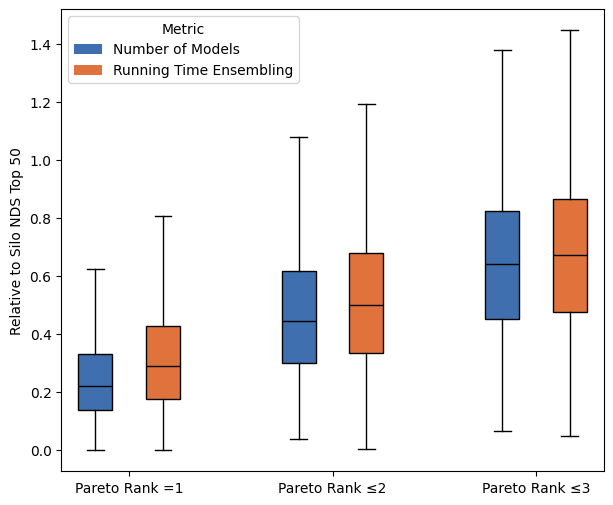

In [22]:
compare_pruning_tradeoffs(TASK_IDS, results_arr, frequency="no-boost", save_path="./figures/ens/ens_pruning_tradeoffs.pdf")

In [23]:
def plot_bmp_ensembling_cd(task_ids, results_arr, frequency, metric, mode="max", metric_rename=None):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = FREQUENCIES.index(frequency)
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)
    metric_vals_mean = np.take(metric_vals_mean, PRUNING_METHODS.index("nd_50_silo"), axis=3)  # shape: (104, 6, 6)
    
    task_ids = np.array([TASK_IDS.index(t) for t in task_ids])
    metric_vals_mean = metric_vals_mean[task_ids]  # shape: (len(task_ids), 6, 6)
    metric_vals_mean_reshape = metric_vals_mean.reshape((len(task_ids), -1))  # shape: (len(task_ids), 36)
    metric_df = pd.DataFrame(
        metric_vals_mean_reshape,
        columns=[
            f"{BMG_METHODS_DICT[b]} + {ENSEMBLING_METHODS_DICT[e]}"
            for b in BMG_METHODS for e in ENSEMBLING_METHODS
        ]
    )
        
    if mode == "min":
        metric_df = -metric_df
        
    fig, ax = plt.subplots(figsize=(10, 6))

    result = autorank.autorank(metric_df, verbose=True, force_mode="nonparametric")
    autorank.plot_stats(result, ax=ax, allow_insignificant=True)
    plt.show()

In [42]:
def plot_bmg_ensembling(task_ids, results_arr, frequency="no-boost", metric="Hypervolume", use_ranks=True, mode="max", metric_rename=None, save_path=None, show_std=True):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = FREQUENCIES.index(frequency)
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)
    metric_vals_mean = np.take(metric_vals_mean, PRUNING_METHODS.index("nd_50_silo"), axis=3)  # shape: (104, 6, 6)
    
    task_ids = np.array([TASK_IDS.index(t) for t in task_ids])
    metric_vals_mean = metric_vals_mean[task_ids]  # shape: (len(task_ids), 6, 6)
    fig= plt.figure(figsize=(len(ENSEMBLING_METHODS)*1.1, 6))
    
    if use_ranks or mode == "min":
        cmap = "viridis_r"
    else:
        cmap = "viridis"
        
            
    if use_ranks:
        metric_vals_reshape = metric_vals_mean.reshape((len(task_ids), -1))  # shape: (104, 36)
        ranks = compute_ranks(metric_vals_reshape, mode=mode, axis=1)  # shape: (104, 36)
        ranks = ranks.reshape((len(task_ids), len(BMG_METHODS), len(ENSEMBLING_METHODS)))  # shape: (104, 6, 6)
        mean_ranks = ranks.mean(axis=0)  # shape: (6, 6)
        std_ranks = ranks.std(axis=0)    # shape: (6, 6)
        # mean_ranks = mean_ranks[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]
        # std_ranks = std_ranks[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]
        
        best_mean_rank = mean_ranks.min()
        best_mean_rank_idx = np.unravel_index(np.argmin(mean_ranks, axis=None), mean_ranks.shape)

        # Combine mean and std into formatted strings
        annot = np.empty(mean_ranks.shape, dtype=object)
        for i in range(mean_ranks.shape[0]):
            for j in range(mean_ranks.shape[1]):
                if show_std:
                    annot[i, j] = f"{mean_ranks[i, j]:.4f}\n({std_ranks[i, j]:.4f})"
                else:
                    annot[i, j] = f"{mean_ranks[i, j]:.4f}"
        sns.heatmap(
            mean_ranks,
            annot=annot,
            fmt="",
            cmap=cmap,
            vmin=mean_ranks.min(),
            vmax=mean_ranks.max(),
            annot_kws={"size": 8},
        )
        
        # Highlight best mean rank
        plt.gca().add_patch(
            Rectangle(
                (best_mean_rank_idx[1], best_mean_rank_idx[0]), 1, 1,
                fill=False, edgecolor="black", linewidth=1.5
            )
        )
    else:
        mean_vals = metric_vals_mean.mean(axis=0)  # shape: (6, 6)
        std_vals = metric_vals_mean.std(axis=0)    # shape: (6, 6)
        # mean_vals = mean_vals[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]
        # std_vals = std_vals[np.ix_([bmg_to_idx[b] for b in BMG_METHODS], [es_to_idx[e] for e in ENSEMBLING_METHODS])]

        # Combine mean and std into formatted strings
        annot = np.empty(mean_vals.shape, dtype=object)
        for i in range(mean_vals.shape[0]):
            for j in range(mean_vals.shape[1]):
                annot[i, j] = f"{mean_vals[i, j]:.4f}\n({std_vals[i, j]:.4f})"
        sns.heatmap(
            mean_vals,
            annot=annot,
            fmt="",
            cmap=cmap,
            vmin=mean_vals.min(),
            vmax=mean_vals.max(),
            annot_kws={"size": 8},
        )
    
    # if any ensembling method contains "+", add a vline to separate those with and without "+"
    plus_indices = [i for i, e in enumerate(ENSEMBLING_METHODS) if "+" in e]
    if len(plus_indices) > 0:
        first_plus_idx = min(plus_indices)
        plt.gca().axvline(first_plus_idx, color="black", linestyle="--", linewidth=1)
        
    # Add a vlina after "bmp"
    bmp_idx = ENSEMBLING_METHODS.index("bmp")
    plt.gca().axvline(bmp_idx + 1, color="black", linestyle="--", linewidth=1)
        
    
    # cbar title
    cbar = plt.gcf().axes[-1]
    cbar.set_ylabel(f"Mean {metric_rename if metric_rename is not None else metric} {'Ranks' if use_ranks else ''}", fontsize=12)
    cbar.tick_params(labelsize=9)
    cbar.yaxis.labelpad = 20
    
    #plt.title(f"{metric} {'(ranks)' if use_ranks else '(raw values)'} - Pruning: Silo NDS Top 50")
    plt.xticks(
        ticks=np.arange(len(ENSEMBLING_METHODS))+0.5,
        labels=[ENSEMBLING_METHODS_DICT[e] if e != "bmp" else "No\nEnsembling" for e in ENSEMBLING_METHODS],
        rotation=45, ha="right", fontsize=8
    )
    plt.yticks(ticks=np.arange(len(BMG_METHODS))+0.5, labels=[BMG_METHODS_DICT[b] for b in BMG_METHODS], rotation=0, fontsize=8)
    
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()

Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column Random Search + BMP (p=0.000273<0.001190)
Fail to reject null hypothesis that data is normal for column Random Search + GES (p=0.005964>=0.001190)
Fail to reject null hypothesis that data is normal for column Random Search + MO-GES (p=0.007705>=0.001190)
Fail to reject null hypothesis that data is normal for column Random Search + QDO-ES (p=0.005479>=0.001190)
Fail to reject null hypothesis that data is normal for column Random Search + Infer-QDO-ES (p=0.004466>=0.001190)
Fail to reject null hypothesis that data is normal for column Random Search + Size-QDO-ES (p=0.004659>=0.001190)
Fail to reject null hypothesis that data is normal for column Random Search + Energy-QDO-ES (p=0.004567>=0.001190)
Rejecting null hypothesis that data is normal for column NSGA-II + BMP (p=0.000131<0.001190)
Fail to reject null hypothesis that data is nor

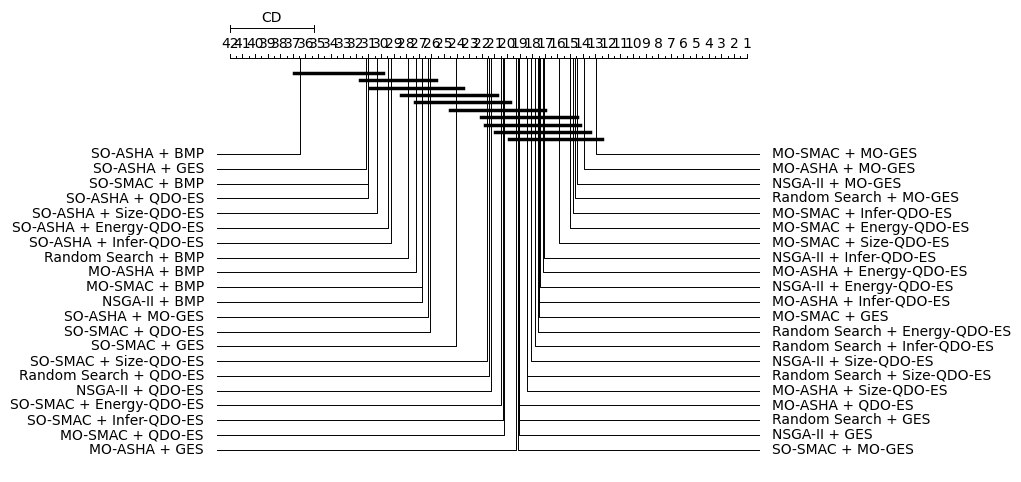

In [43]:
plot_bmp_ensembling_cd(TASK_IDS, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", mode="max", metric_rename="Hypervolume")

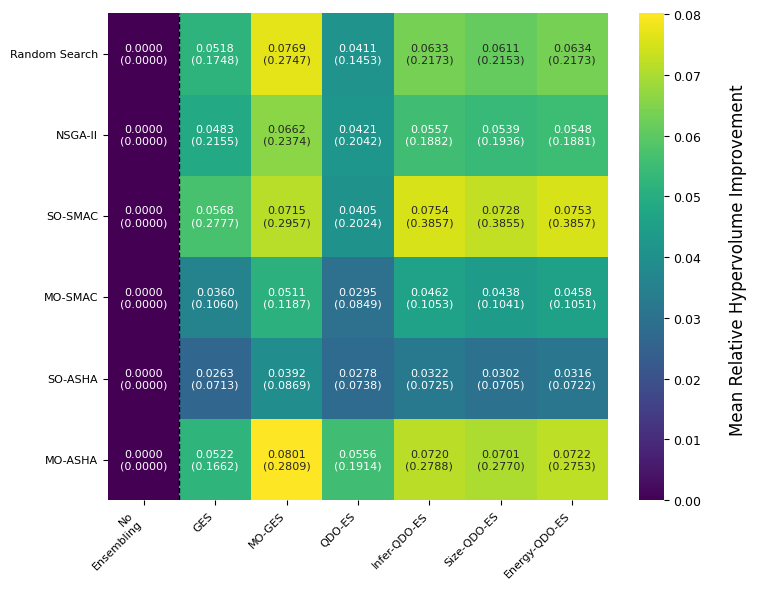

In [44]:
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Relative Log Hypervolume Improvement", use_ranks=False, mode="max", metric_rename="Relative Hypervolume Improvement", save_path="./figures/ens/ens_bmg_ensembling_hv_rel.pdf")

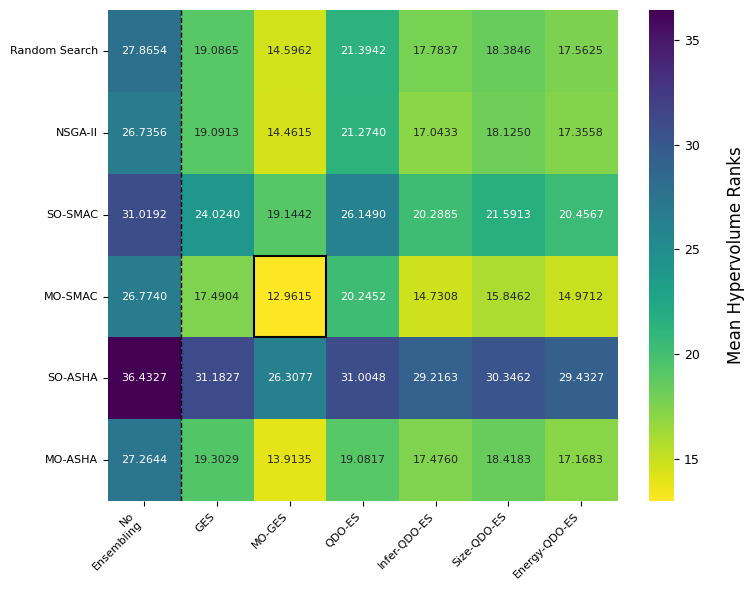

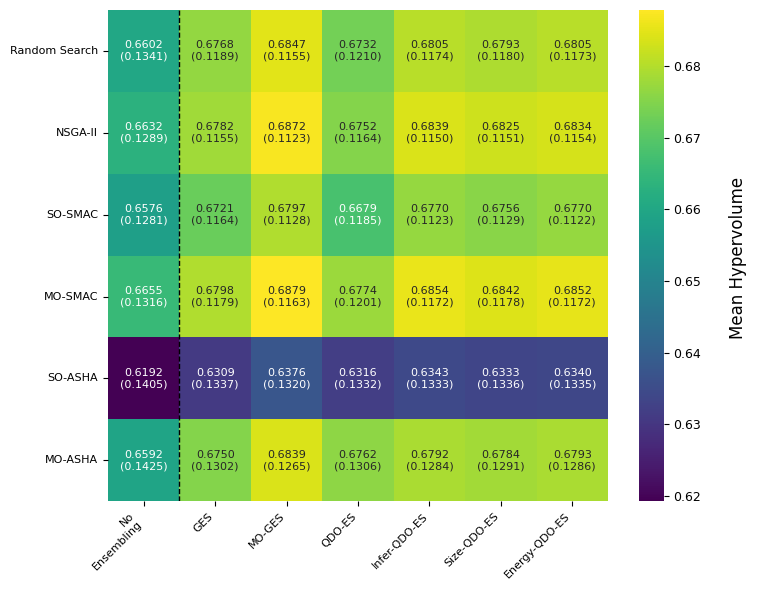

In [45]:
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", use_ranks=True, mode="max", metric_rename="Hypervolume", save_path="./figures/ens/ens_bmg_ensembling_hv_ranks.pdf", show_std=False)
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", use_ranks=False, mode="max", metric_rename="Hypervolume", save_path="./figures/ens/ens_bmg_ensembling_hv_values.pdf")

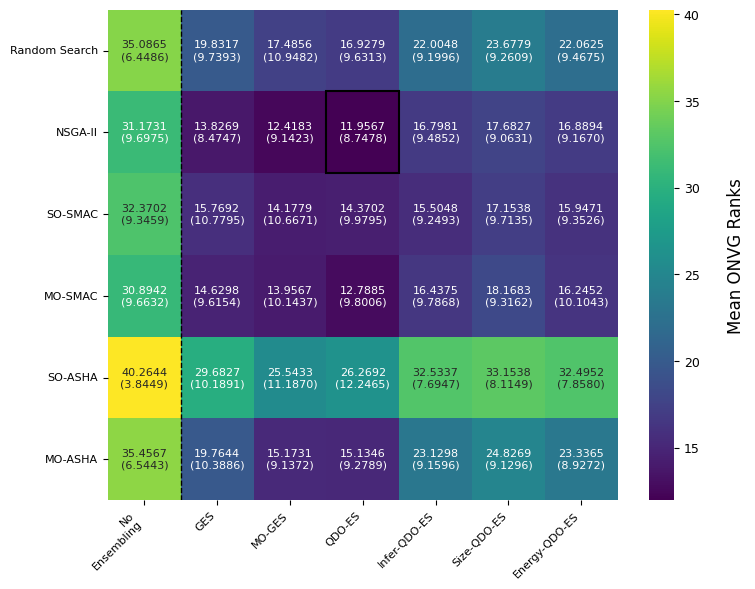

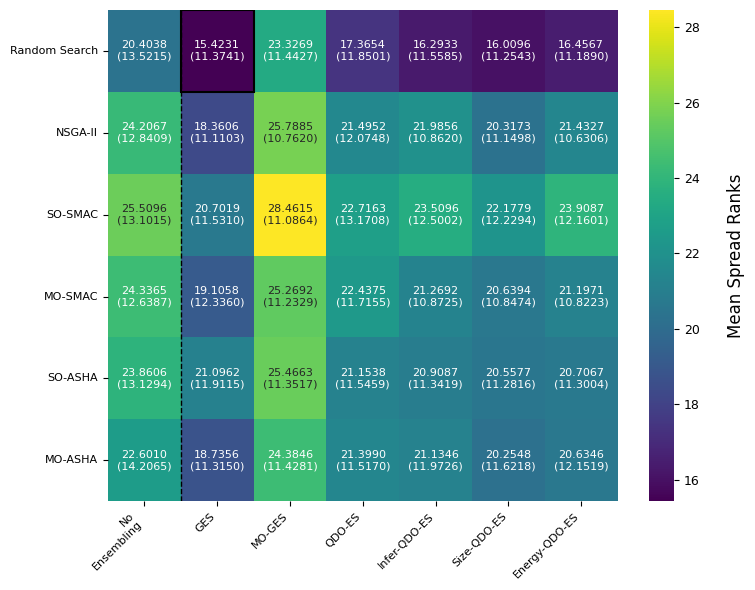

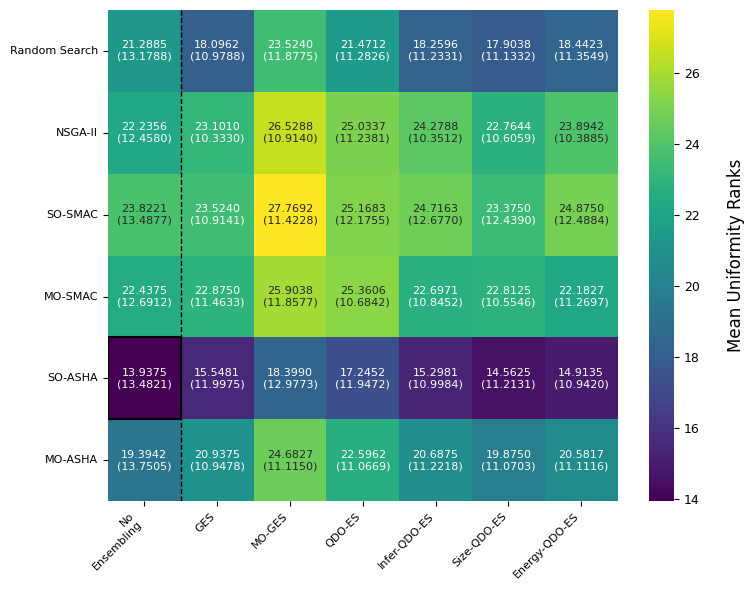

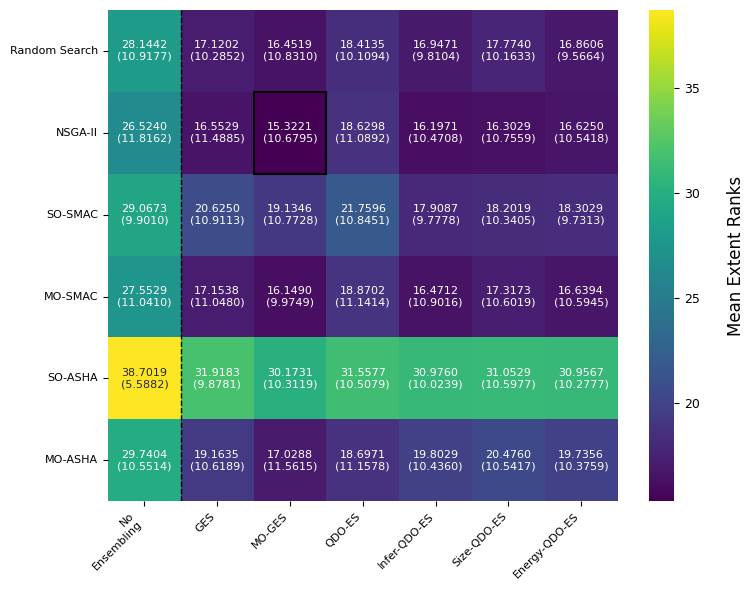

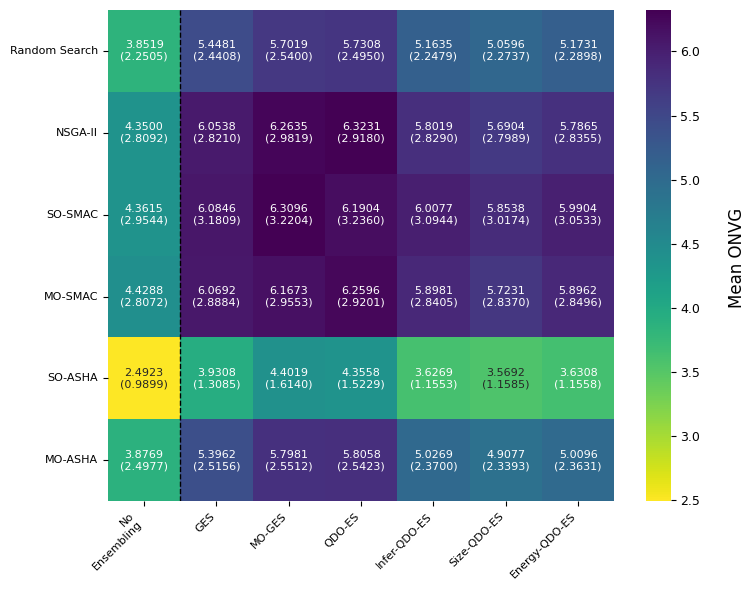

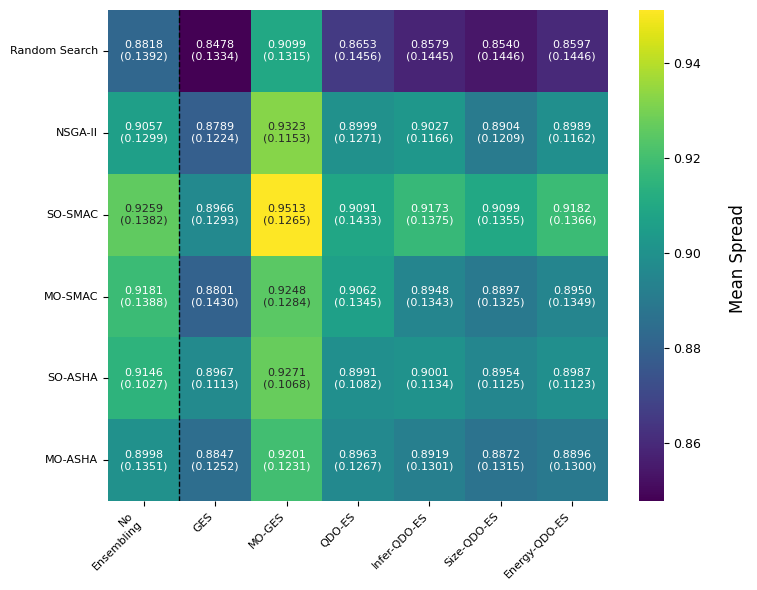

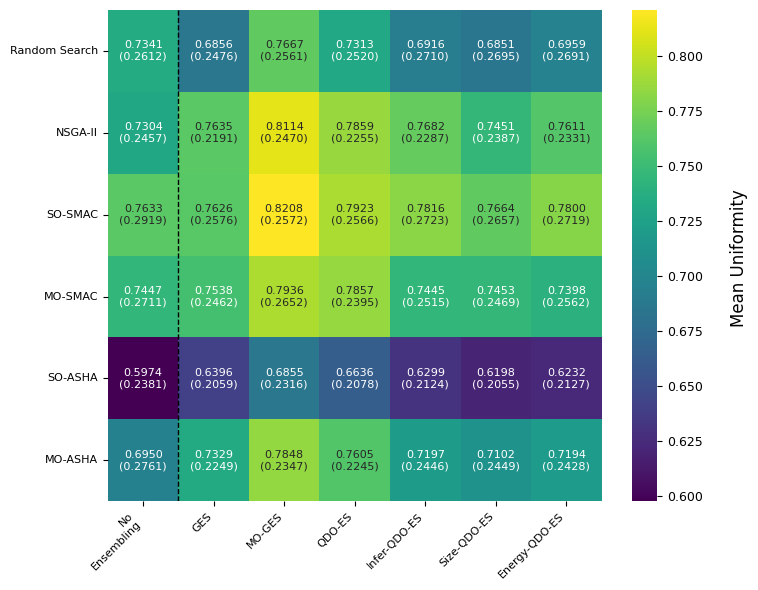

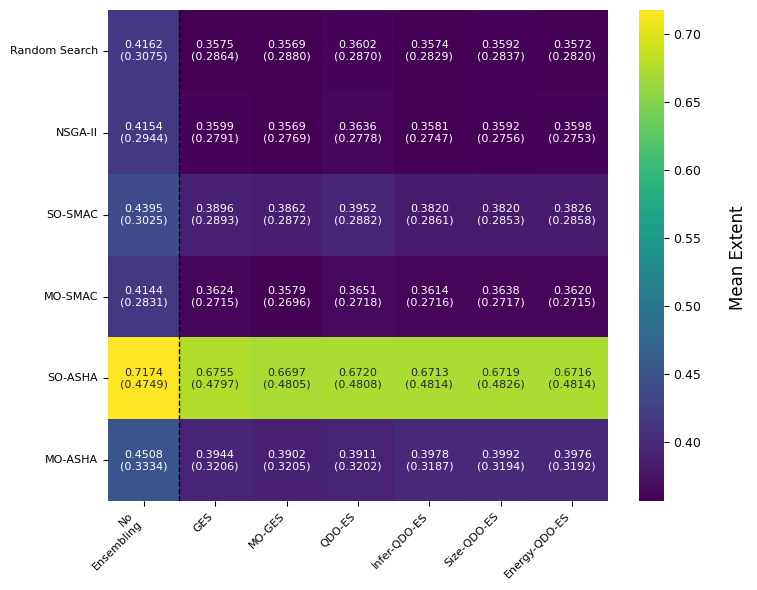

In [28]:
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Size of Pareto Front incl. BMP", mode="max", metric_rename="ONVG", save_path="./figures/ens/ens_bmg_ensembling_onvg.pdf")
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Spread incl. BMP", mode="min", metric_rename="Spread", save_path="./figures/ens/ens_bmg_ensembling_spread.pdf")
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Uniformity Full", mode="min", metric_rename="Uniformity", save_path="./figures/ens/ens_bmg_ensembling_uniformity.pdf")
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Extent Full", mode="min", metric_rename="Extent", save_path="./figures/ens/ens_bmg_ensembling_extent.pdf")

plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Size of Pareto Front incl. BMP", mode="max", metric_rename="ONVG", use_ranks=False)
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Spread incl. BMP", mode="min", metric_rename="Spread", use_ranks=False)
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Uniformity Full", mode="min", metric_rename="Uniformity", use_ranks=False)
plot_bmg_ensembling(TASK_IDS, results_arr, frequency="no-boost", metric="Extent Full", mode="min", metric_rename="Extent", use_ranks=False)

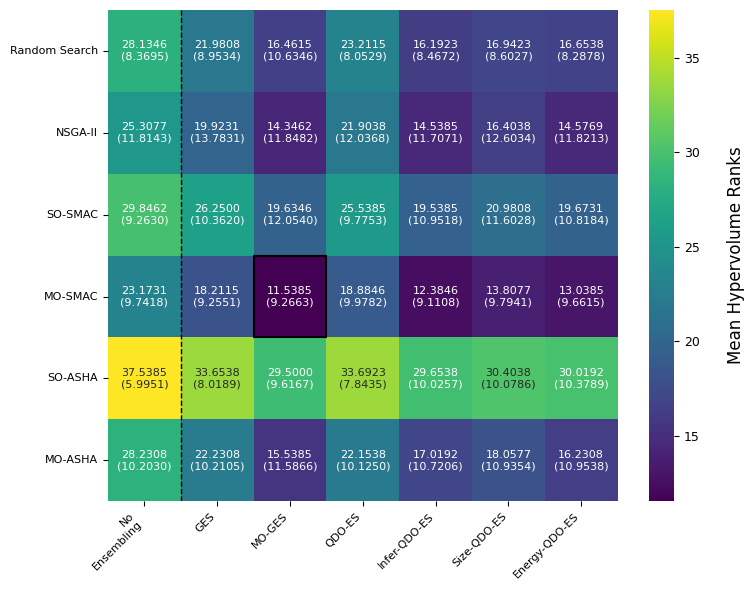

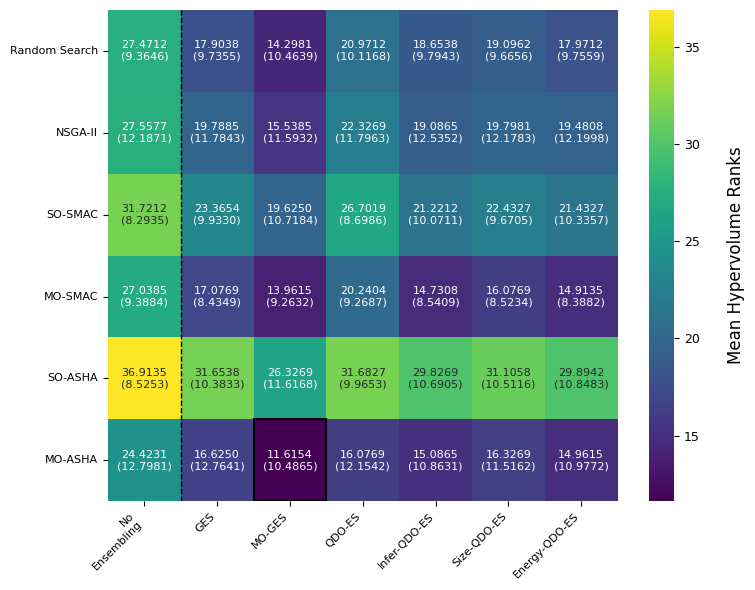

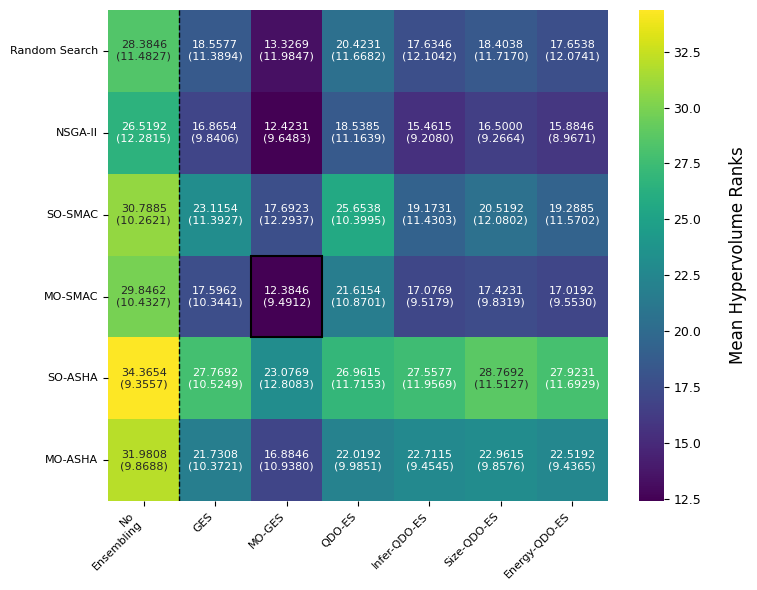

In [29]:
fast = get_group_task_ids("fast")
plot_bmg_ensembling(fast, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", mode="max", metric_rename="Hypervolume", save_path="./figures/ens/ens_bmg_ensembling_hv_fast.pdf")
medium = get_group_task_ids("medium")
plot_bmg_ensembling(medium, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", mode="max", metric_rename="Hypervolume", save_path="./figures/ens/ens_bmg_ensembling_hv_medium.pdf")
slow = get_group_task_ids("slow")
plot_bmg_ensembling(slow, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", mode="max", metric_rename="Hypervolume", save_path="./figures/ens/ens_bmg_ensembling_hv_slow.pdf")

In [30]:
import autorank
from colors import COLORS

COLOR_LIST= list(COLORS.values())

def compute_nonsig_groups(mean_ranks, cd):
    """
    mean_ranks: array of shape (M,) with mean ranks for each treatment
    cd: critical distance
    
    Returns a list of groups (each group is a list of indices)
    that are NOT significantly different.
    """
    M = len(mean_ranks)
    
    # Sort indices by mean rank
    sorted_idx = np.argsort(mean_ranks)
    sorted_ranks = mean_ranks[sorted_idx]
    
    groups = []
    i = 0
    while i < M:
        group = [sorted_idx[i]]
        j = i + 1
        while j < M:
            # If difference between ranks <= CD, treatments are NOT significantly different
            if sorted_ranks[j] - sorted_ranks[i] <= cd:
                group.append(sorted_idx[j])
                j += 1
            else:
                break
        groups.append(group)
        i = i+1  # move to next group

    def is_subset(small, big):
        return all(item in big for item in small)

    groups = [g for g in groups if len(g) > 1]
    sorted_groups = sorted(groups, key=lambda x: len(x), reverse=False)

    remove_indices = []
    for i in range(len(sorted_groups)):
        if any(is_subset(sorted_groups[i], sorted_groups[j]) for j in range(len(sorted_groups)) if j != i):
            remove_indices.append(i)

    return [sorted_groups[i] for i in range(len(sorted_groups)) if i not in remove_indices]


def create_cd_2d(mean_ranks, cd, diagram_names, treatment_names, x_label=None, save_path=None):
    fig, ax = plt.subplots(figsize=(9, 6))

    # Remove borders and ticks
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(length=0)

    # Set ticks and grid
    ax.set_xticks(1 + np.arange(len(treatment_names)))  # x grid every 1 unit
    ax.set_yticks(np.arange(len(diagram_names)))
    ax.grid(True, alpha=0.6)
    ax.invert_xaxis()  # Invert x-axis
    ax.set_xlim(1, len(treatment_names)+.005)

    # Y-axis labels
    ax.set_yticklabels(diagram_names[::-1], ha="right", fontsize=14)
    ax.set_xticklabels(1 + np.arange(len(treatment_names)), fontsize=14)

    if x_label is not None:
        ax.set_xlabel(x_label, fontsize=16)

    # Scatter plot
    treatment_colors, treatment_markers = zip(*product(COLOR_LIST[1:], ["s","o", "*","x","^","2"]))
    treatment_colors = [COLOR_LIST[0]] + list(treatment_colors)
    treatment_markers = ["s"] + list(treatment_markers)
    
    scatter_handles = []

    for i, diagram_name in enumerate(diagram_names):
        ranks = mean_ranks[i]
        cd_val = cd[i]

        groups_nonsig = compute_nonsig_groups(ranks, cd_val)
        for i_group, group in enumerate(groups_nonsig):
            group_ranks = ranks[group]
            x_start = group_ranks.min()
            x_end = group_ranks.max()
            y_pos = len(diagram_names) - 1 - i - 0.2 - i_group * 0.1
            ax.hlines(y=y_pos, xmin=x_start, xmax=x_end, color='black', linewidth=1)
            #ax.vlines(x=x_start, ymin=y_pos, ymax=y_pos + 0.05, color='black', linewidth=1)
            #ax.vlines(x=x_end, ymin=y_pos, ymax=y_pos + 0.05, color='black', linewidth=1)

        for j, treatment_name in enumerate(treatment_names):
            sc = ax.scatter(
                ranks[j], len(diagram_names) - 1 - i, 
                marker=treatment_markers[j % len(treatment_markers)],
                color=treatment_colors[j % len(treatment_colors)], 
                s=100, alpha=1,
            )
            scatter_handles.append(sc)
            groups_with_j_indices = [i for i, g in enumerate(groups_nonsig) if j in g]
            max_index = max(groups_with_j_indices) if groups_with_j_indices else -1
            if max_index >= 0:
                ax.vlines(x=ranks[j], ymin=len(diagram_names) - 1 - i, ymax=len(diagram_names) - 1 - i - 0.2 - (max_index * 0.1), linewidth=1, color="black", linestyles="dotted")        

    # Legend outside to the right
    plt.legend(
        handles=scatter_handles[:len(treatment_names)],  # only scatter points
        labels=treatment_names,
        bbox_to_anchor=(1, 0.5),
        loc='center left',
        fontsize=14
    )

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()




def plot_cds(task_ids, results_arr, frequency="no-boost", metric="Hypervolume", mode="max", metric_rename=None, save_path=None):
    metric_vals = np.take(results_arr, RESULTS_ORDER.index(metric), axis=-1)
    freq_idx = FREQUENCIES.index(frequency)
    metric_vals = np.take(metric_vals, freq_idx, axis=0)  # shape: (104, 6, 5, 6, 7)
    metric_vals_mean = np.mean(metric_vals, axis=2)  # shape: (104, 6, 6, 7)
    metric_vals_mean = np.take(metric_vals_mean, PRUNING_METHODS.index("nd_50_silo"), axis=3)  # shape: (104, 6, 6)

    fig, ax = plt.subplots(figsize=(15, 8), ncols=2, nrows=3)
    ax = ax.flatten()

    mean_ranks = []
    cds = []

    for i, bmg_method in enumerate(BMG_METHODS):
        i_bmg = BMG_METHODS.index(bmg_method)
        data = metric_vals_mean[:, i_bmg, :]  # shape: (104, 6)
        data = data[[TASK_IDS.index(t) for t in task_ids]]  # shape: (len(task_ids), 6)
        metric_df = pd.DataFrame(data, columns=[ENSEMBLING_METHODS_DICT[e] for e in ENSEMBLING_METHODS])
        
        if mode == "min":
            metric_df = -metric_df

        result = autorank.autorank(metric_df, verbose=True, force_mode="nonparametric")
        autorank.plot_stats(result, ax=ax[i], allow_insignificant=True)
        ax[i].set_title(BMG_METHODS_DICT[bmg_method], fontsize=16)

        mean_ranks.append(result.rankdf["meanrank"])
        cds.append(result.cd)

    fig.subplots_adjust(
        left=0.05,
        right=0.95,
        bottom=0.0,
        top=1.0,
        wspace=0.5,
        hspace=0.2
    )
    plt.show()

    mean_ranks_array = np.array([[mr_df[ENSEMBLING_METHODS_DICT[e]] for e in ENSEMBLING_METHODS] for mr_df in mean_ranks])

    create_cd_2d(
        mean_ranks_array,
        np.array(cds),
        diagram_names = [BMG_METHODS_DICT[m] for m in BMG_METHODS],
        treatment_names = [ENSEMBLING_METHODS_DICT[e] for e in ENSEMBLING_METHODS],
        x_label=f"Mean {metric_rename if metric_rename else metric} Rank",
        save_path=save_path
    )


Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column BMP (p=0.000273<0.007143)
Rejecting null hypothesis that data is normal for column GES (p=0.005964<0.007143)
Fail to reject null hypothesis that data is normal for column MO-GES (p=0.007705>=0.007143)
Rejecting null hypothesis that data is normal for column QDO-ES (p=0.005479<0.007143)
Rejecting null hypothesis that data is normal for column Infer-QDO-ES (p=0.004466<0.007143)
Rejecting null hypothesis that data is normal for column Size-QDO-ES (p=0.004659<0.007143)
Rejecting null hypothesis that data is normal for column Energy-QDO-ES (p=0.004567<0.007143)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.905162>=0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemeny

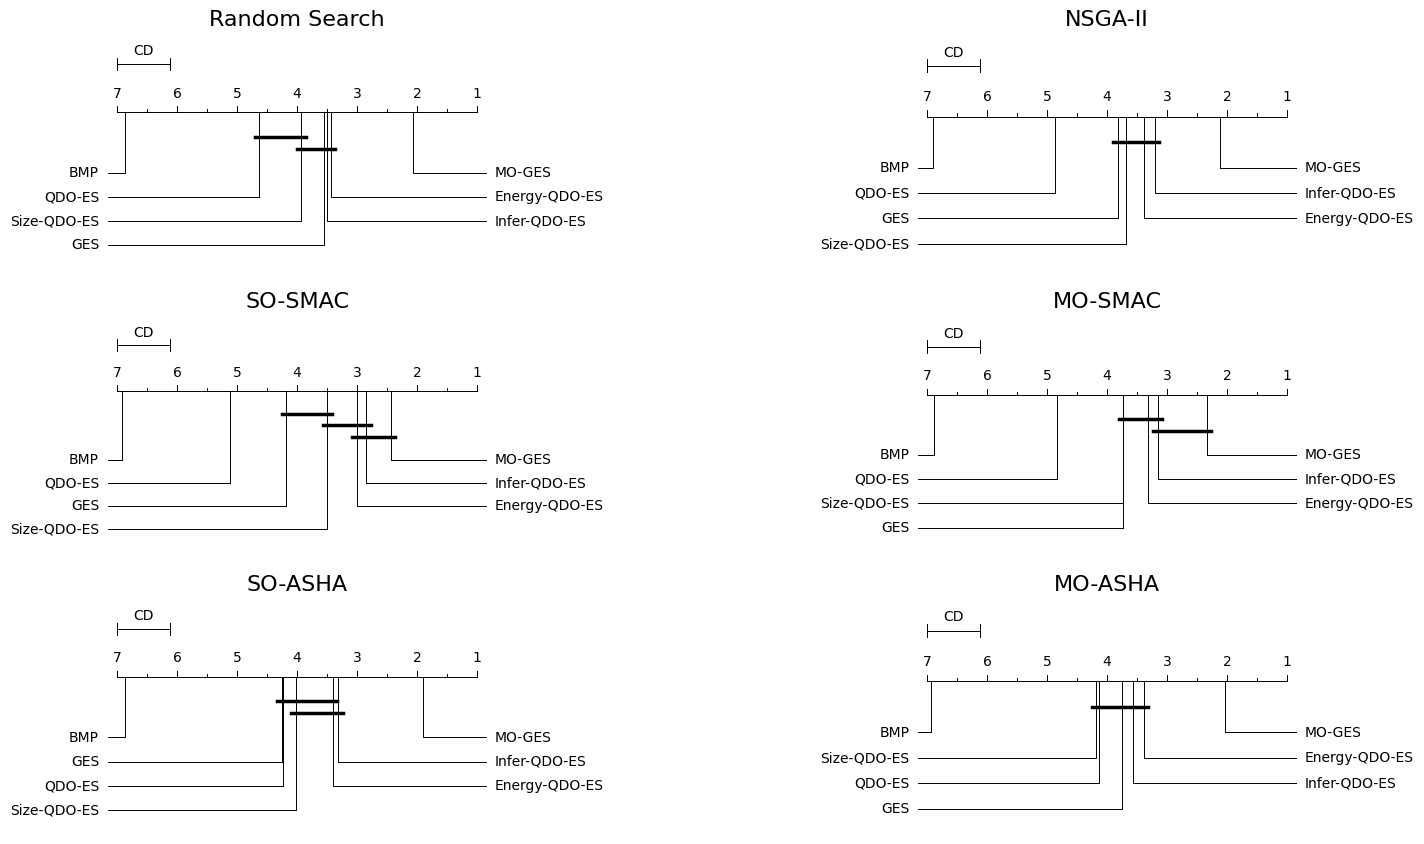

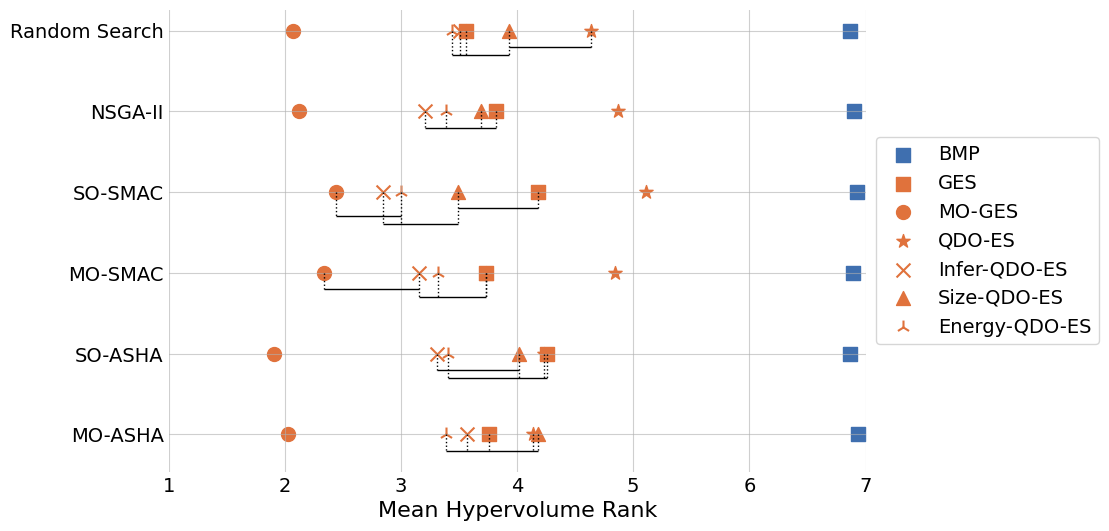

In [31]:
plot_cds(TASK_IDS, results_arr, frequency="no-boost", metric="Log Hypervolume incl. BMP", mode="max", metric_rename="Hypervolume", save_path="./figures/ens/ens_bmg_ensembling_cds.pdf")

Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column BMP (p=0.285500>=0.007143)
Fail to reject null hypothesis that data is normal for column GES (p=0.041893>=0.007143)
Rejecting null hypothesis that data is normal for column MO-GES (p=0.000919<0.007143)
Fail to reject null hypothesis that data is normal for column QDO-ES (p=0.020895>=0.007143)
Fail to reject null hypothesis that data is normal for column Infer-QDO-ES (p=0.038390>=0.007143)
Fail to reject null hypothesis that data is normal for column Size-QDO-ES (p=0.039941>=0.007143)
Fail to reject null hypothesis that data is normal for column Energy-QDO-ES (p=0.034402>=0.007143)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.877881>=0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distribut

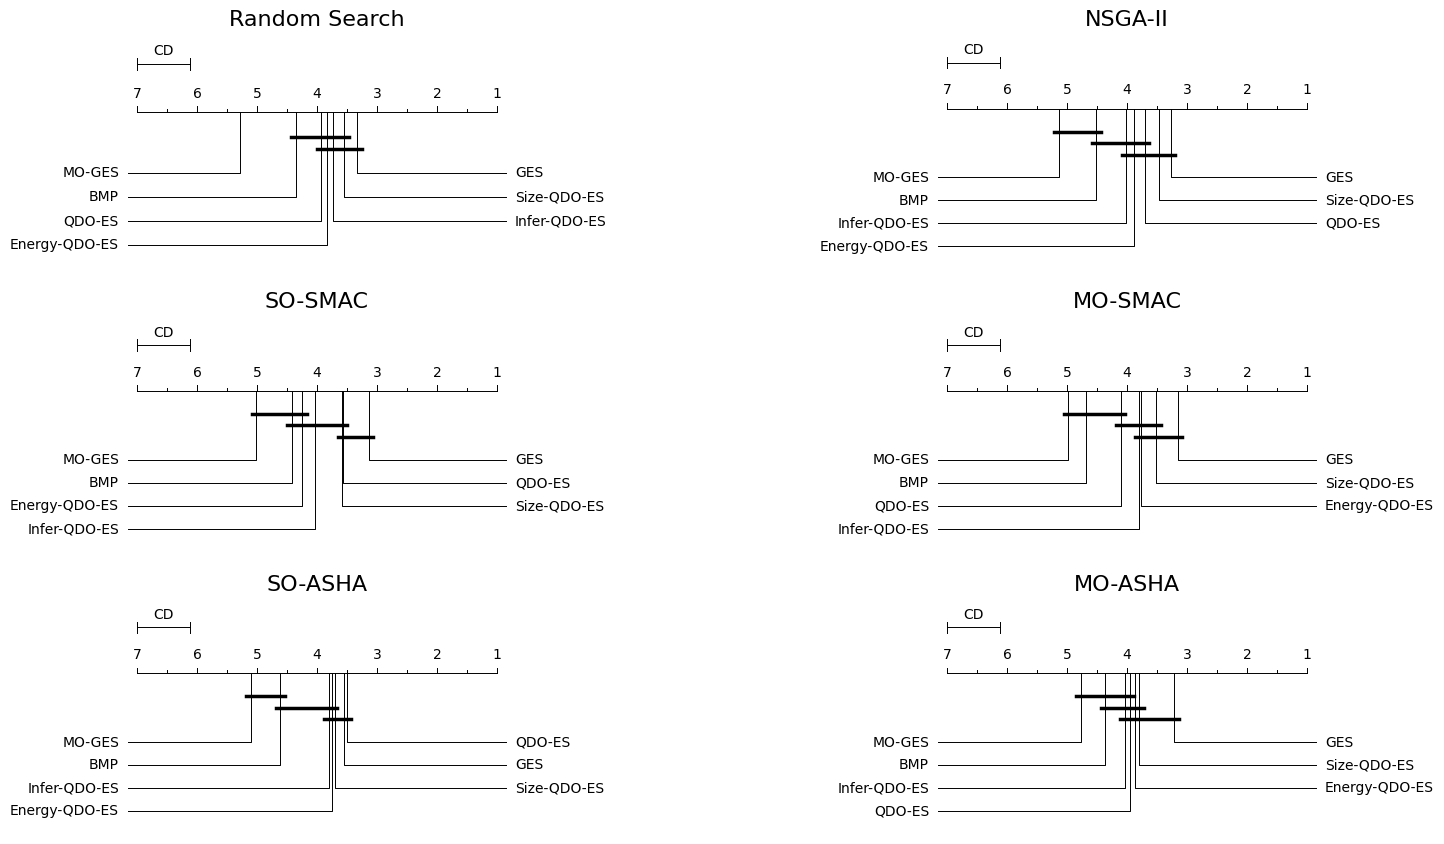

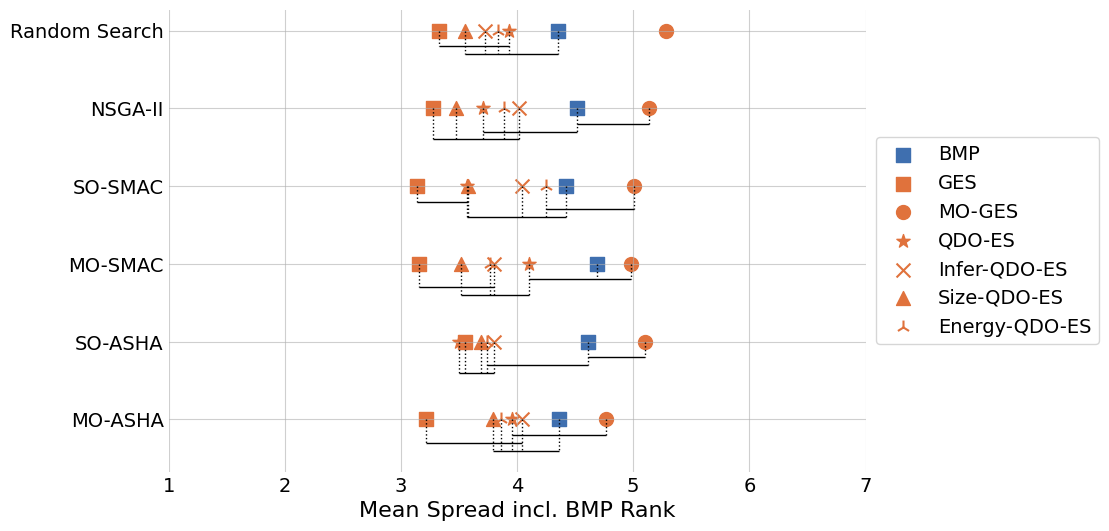

In [32]:
plot_cds(TASK_IDS, results_arr, frequency="no-boost", metric="Spread incl. BMP", mode="min")

Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column BMP (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column GES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column MO-GES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column QDO-ES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column Infer-QDO-ES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column Size-QDO-ES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column Energy-QDO-ES (p=0.000000<0.007143)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.969448>=0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post

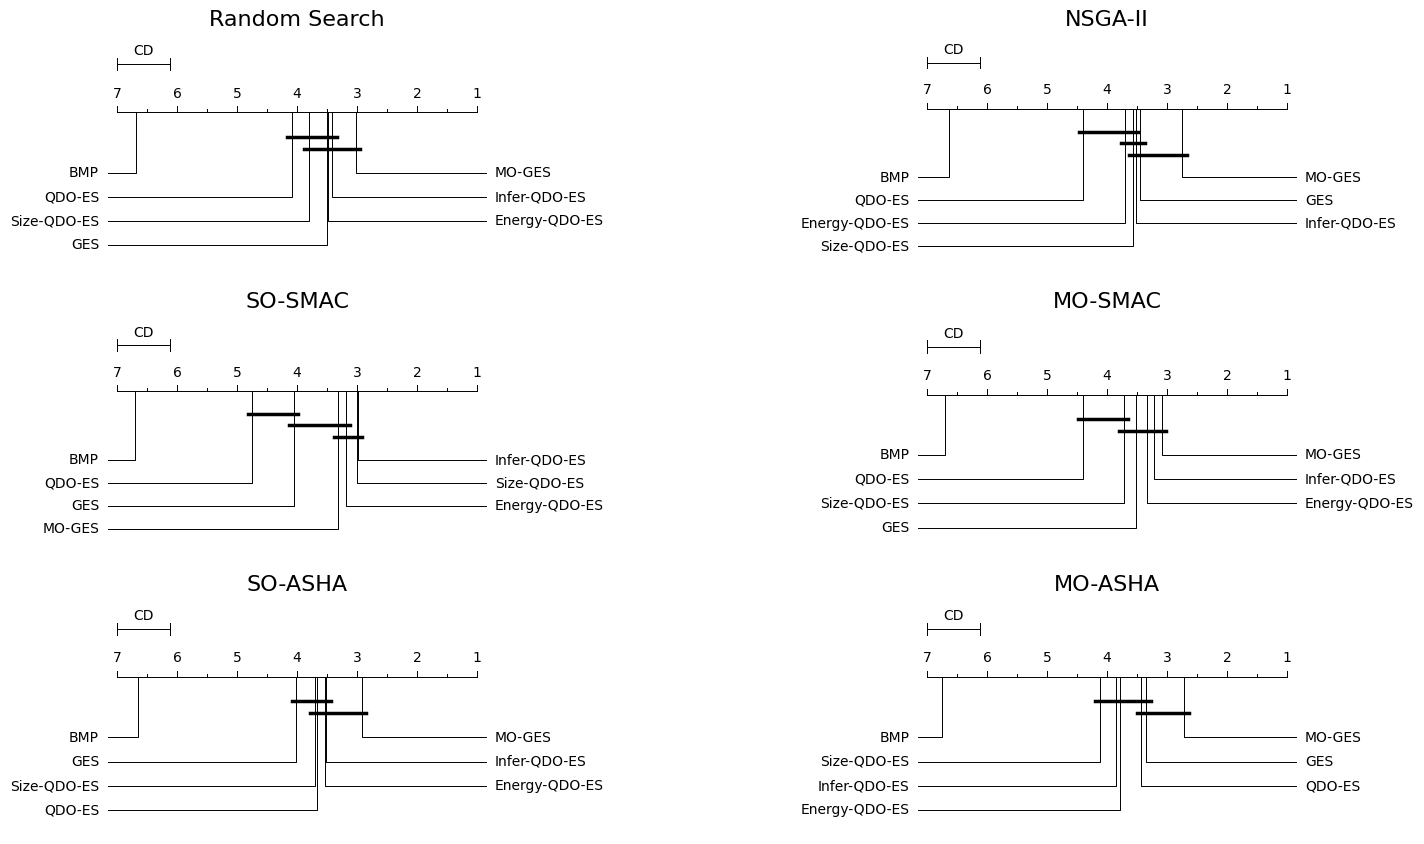

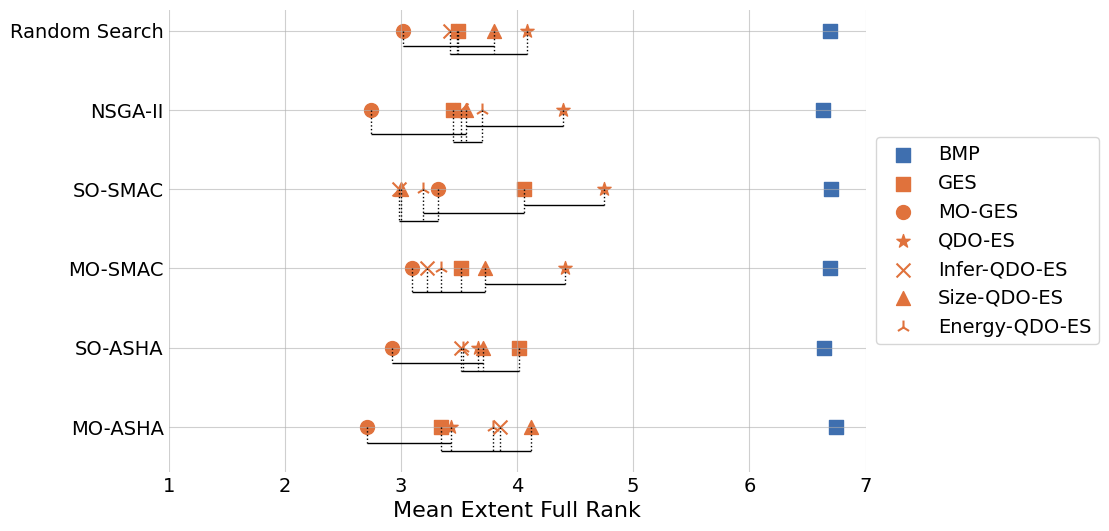

In [33]:
plot_cds(TASK_IDS, results_arr, frequency="no-boost", metric="Extent Full", mode="min")

Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Fail to reject null hypothesis that data is normal for column BMP (p=0.895066>=0.007143)
Fail to reject null hypothesis that data is normal for column GES (p=0.919060>=0.007143)
Fail to reject null hypothesis that data is normal for column MO-GES (p=0.607246>=0.007143)
Fail to reject null hypothesis that data is normal for column QDO-ES (p=0.954653>=0.007143)
Fail to reject null hypothesis that data is normal for column Infer-QDO-ES (p=0.698804>=0.007143)
Fail to reject null hypothesis that data is normal for column Size-QDO-ES (p=0.692535>=0.007143)
Fail to reject null hypothesis that data is normal for column Energy-QDO-ES (p=0.632499>=0.007143)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.953970>=0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference betw

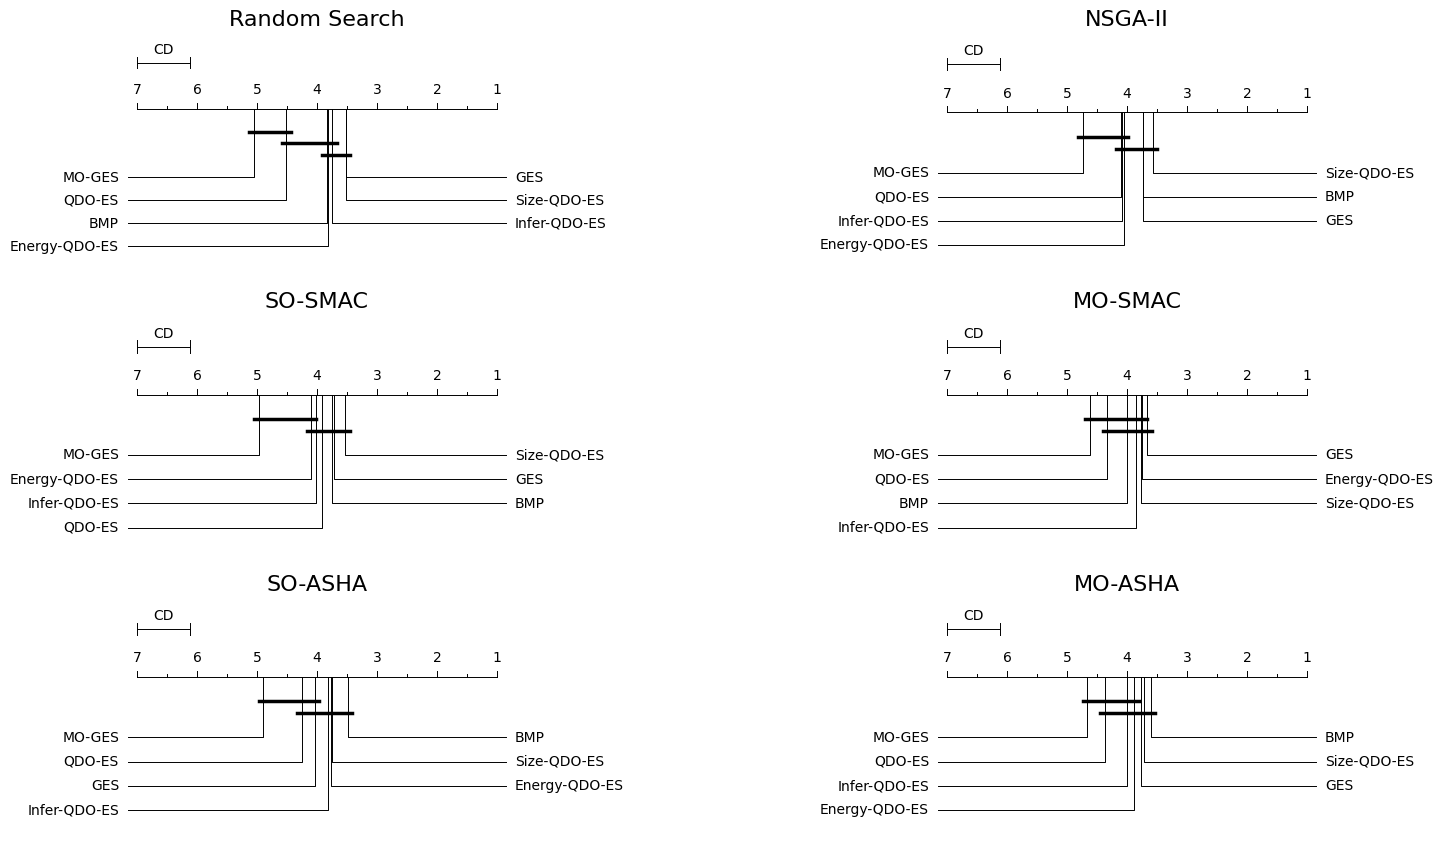

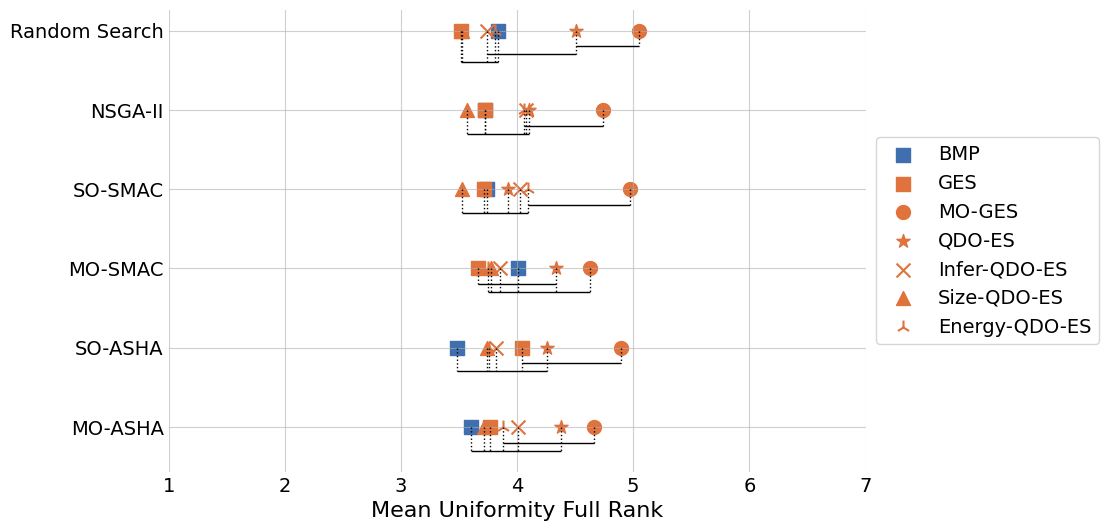

In [34]:
plot_cds(TASK_IDS, results_arr, frequency="no-boost", metric="Uniformity Full", mode="min")

Tests for normality and homoscedacity are ignored for test selection, forcing nonparametric tests
Rejecting null hypothesis that data is normal for column BMP (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column GES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column MO-GES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column QDO-ES (p=0.000000<0.007143)
Rejecting null hypothesis that data is normal for column Infer-QDO-ES (p=0.000001<0.007143)
Rejecting null hypothesis that data is normal for column Size-QDO-ES (p=0.000001<0.007143)
Rejecting null hypothesis that data is normal for column Energy-QDO-ES (p=0.000001<0.007143)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.013729<0.050000)
Using Friedman test as omnibus test
Rejecting null hypothesis that there is no difference between the distributions (p=0.000000)
Using Nemenyi post-hoc t

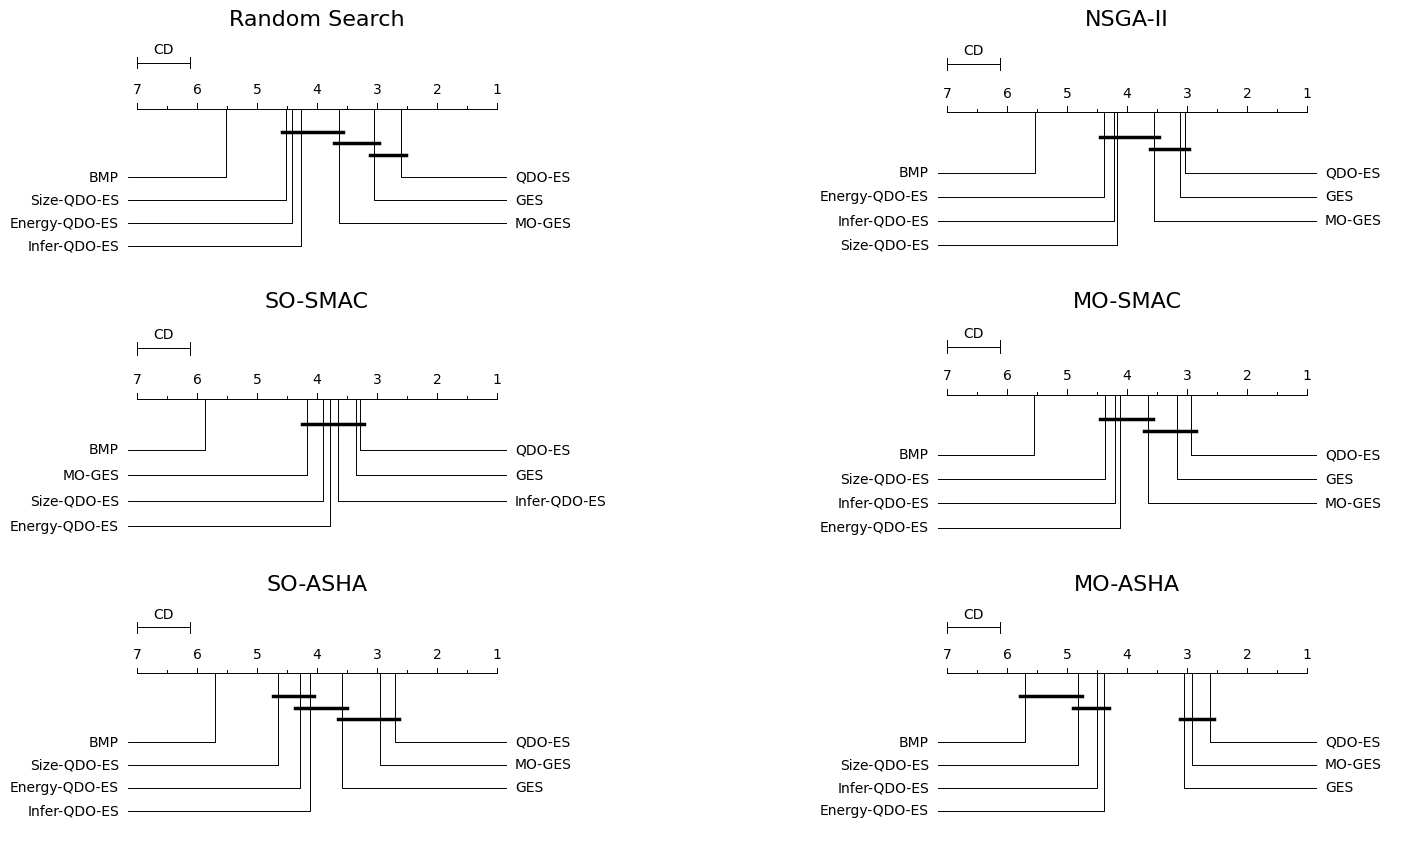

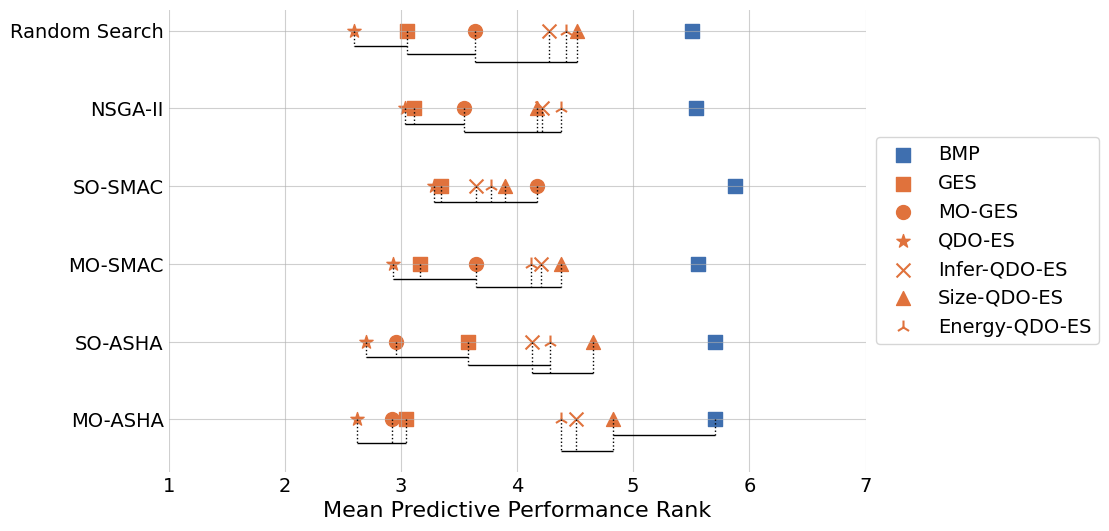

In [35]:
plot_cds(TASK_IDS, results_arr, frequency="no-boost", metric="Predictive Metric Ensembling", mode="min", metric_rename="Predictive Performance")

In [36]:
def plot_runtimes(task_groups, frequency, runtimes, bmg_method, pruning_method, save_path=None):
    if isinstance(task_groups, list):
        task_groups = {"": task_groups}

    # Filter by frequency, BMG method, and pruning
    runtimes_filtered = np.take(runtimes, FREQUENCIES.index(frequency), axis=0)
    i_bmg = BMG_METHODS.index(bmg_method)
    runtimes_filtered = np.take(runtimes_filtered, i_bmg, axis=1)
    runtimes_filtered = np.take(runtimes_filtered, PRUNING_METHODS.index(pruning_method), axis=-1)

    fig, ax = plt.subplots(figsize=(6+len(task_groups), 5))

    # Colors for task groups
    palette = COLOR_LIST
    group_colors = {name: palette[i % len(palette)] for i, name in enumerate(task_groups.keys())}

    legend_handles = []

    positions = []
    cluster_centers = []
    pos = 1

    # Iterate through ensembling methods
    for method in [e for e in ENSEMBLING_METHODS if e not in ["bmp", "ges"]]:
        cluster_start = pos

        for group_name, task_ids in task_groups.items():
            task_indices = [TASK_IDS.index(tid) for tid in task_ids]
            runtimes_group = np.take(runtimes_filtered, task_indices, axis=0)
            runtimes_mean = np.mean(runtimes_group, axis=1)

            # relative to GES
            ges_runtime = runtimes_mean[:, ENSEMBLING_METHODS.index("ges")]  #np.mean(np.take(runtimes_group, ENSEMBLING_METHODS.index("ges"), axis=1), axis=1, keepdims=True)
            rel_runtime = runtimes_mean[:, ENSEMBLING_METHODS.index(method)] / ges_runtime #ges_runtime.flatten()

            bp = ax.boxplot(
                rel_runtime,
                positions=[pos],
                widths=0.8,
                showfliers=True,
                patch_artist=True
            )
            for patch in bp["boxes"]:
                patch.set_facecolor(group_colors[group_name])
            for median in bp["medians"]:
                median.set_color("black")

            positions.append(pos)
            pos += 1

            # legend handle
            if group_name not in [h.get_label() for h in legend_handles]:
                legend_handles.append(
                    plt.Line2D([0], [0], color=group_colors[group_name], lw=8, label=group_name)
                )

        cluster_end = pos - 1
        cluster_centers.append((cluster_start + cluster_end) / 2)

        # gap between clusters
        pos += 1

    # ----- X-Axis: ensembling method labels -----
    ax.axhline(y=1.0, alpha=0.5, color="gray", linestyle="--", label="GES Baseline")
    method_labels = [ENSEMBLING_METHODS_DICT[m] for m in ENSEMBLING_METHODS if m not in ["ges", "bmp"]]
    ax.set_xticks(cluster_centers)
    ax.set_xticklabels(["+\n".join(m.split("+")) for m in method_labels], rotation=0, fontsize=9)

    #ax.set_title(f"Relative Runtimes (BMG: {BMG_METHODS_DICT[bmg_method]}, "
    #             f"Pruning: {PRUNING_METHODS_DICT[pruning_method]})")
    ax.set_ylabel("Running Time Relative to GES Running Time")

    if len(legend_handles) > 1:
        ax.legend(handles=legend_handles, title="Task Groups", title_fontsize=12)
    plt.tight_layout()
    
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()


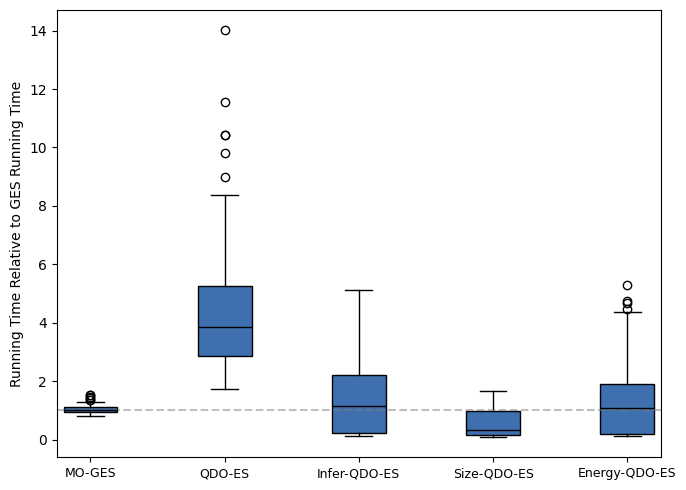

In [37]:
runtimes_ensembling = np.take(results_arr, RESULTS_ORDER.index("Runtime Ensembling"), axis=-1)
plot_runtimes(TASK_IDS, "no-boost", runtimes_ensembling, bmg_method="mo-smac", pruning_method="nd_50_silo", save_path="./figures/ens/ens_runtimes.pdf")

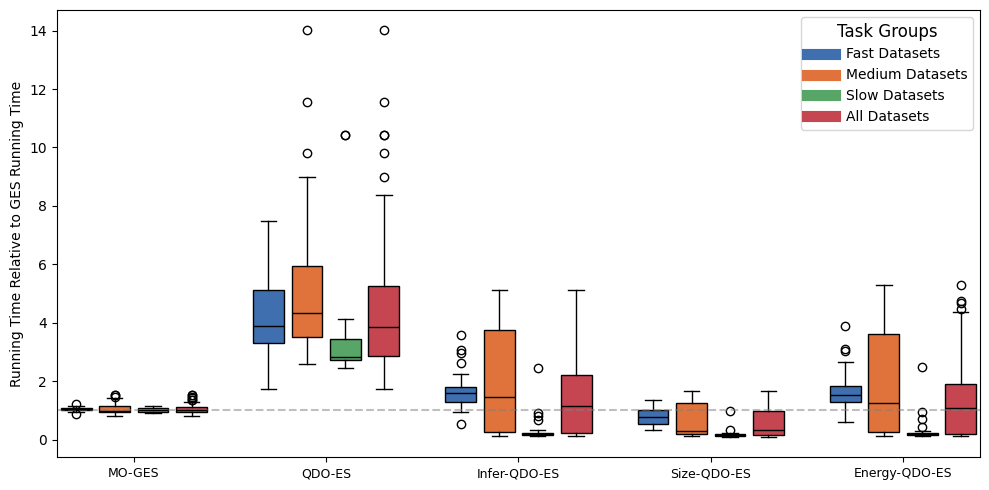

In [38]:
slow_ids = get_group_task_ids("slow")
medium_ids = get_group_task_ids("medium")
fast_ids = get_group_task_ids("fast")

data_dict = {
    "Fast Datasets": fast_ids,
    "Medium Datasets": medium_ids,
    "Slow Datasets": slow_ids,
    "All Datasets": TASK_IDS
}

plot_runtimes(data_dict, "no-boost", runtimes_ensembling, bmg_method="mo-smac", pruning_method="nd_50_silo")